Engagement (Figs 2.1, 4). What motivates someone to participate in a drawing? We could compare subreddit popularity and associated drawing sizes. See if people are more likely to participate when the drawing is growing. If engagement is larger in large or small drawings. This can be done for the 3 experiments and based only on drawings in the atlas.

In [118]:
import csv
import numpy as np
from analysis import *
import sys
#import basic libraries

import os
import math
import numpy.linalg as npla
import scipy
from scipy import sparse
from scipy import linalg
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt 
from matplotlib import cm
from scipy.fftpack import fft, fftfreq
from statsmodels.tsa.seasonal import seasonal_decompose

import matplotlib.mlab as mlab
from mpl_toolkits.mplot3d import axes3d
#%matplotlib tk
import operator
#import datashader as ds
#from datashader.mpl_ext import dsshow
import mpl_scatter_density
from matplotlib.colors import LinearSegmentedColormap

# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '/home/yw180/place/analysis/Python_code/')
from project_data_analysis import pixels_per_project, Create_Array

In [101]:
atlas_path = "/scratch/yw180/place/data/"
RC_path = "/scratch/tl107/reddit_thread/filtered_data/"
#r/place only, Technology, Region, Other, Game, Screen Entertainment, Celebrity, University, Sports, YouTubers/Streamers
colors={"r/place only":"#e60049","Technology":"#0076bf", "Region":"#abdda4", "Other":"#b9b9b9",
        "Game":"#e6d800", "Screen Entertainment":"#9b19f5","Celebrity":"#ffa300", 
        "University":"#dc0ab4", "Sports":"#0b5a00", "YouTubers/Streamers":"#ffffbf"}
subreddit_category_path = "/scratch/yw180/reddit_thread/2017_subreddit_category.csv"

In [102]:

# RC_path = "/scratch/tl107/reddit_thread/filtered_data/"

subr_id = subreddit_id_17(atlas_path+"atlas_complete.json")

posts_per_proj = posts_per_project(RC_path+"RS_Successful_Artworks")
comm_post_per_proj = comment_posts_per_project(RC_path+"RS_Successful_Artworks", RC_path+"RC_Successful_Artworks")
u_per_proj = users_per_project(RC_path+"RS_Successful_Artworks", RC_path+"RC_Successful_Artworks")
u_per_proj = {key: len(val) for key, val in u_per_proj.items()}
comm_per_proj = comments_per_project(RC_path+"RC_Successful_Artworks")

{'id': 1800, 'submitted_by': 'Hosko', 'name': 'Flag of Gibraltar', 'description': 'Before the void overcame this space in the final day, there was a Flag of Gibraltar here.', 'website': '', 'subreddit': '', 'center': [183.5, 388.5], 'path': [[176.5, 383.5], [191.5, 383.5], [191.5, 393.5], [175.5, 393.5], [176.5, 391.5], [175.5, 391.5], [175.5, 386.5], [175.5, 386.5], [175.5, 383.5], [175.5, 383.5]]}


# posts, comments, users vs. pixels

In [166]:
def convert_subreddit_to_id(subr_id, other_dict):
    output = dict()
    for key in other_dict:
        nums = subr_id[key] 
        for num in nums:
            if num not in output:
                output[num] = 0
            output[num] += other_dict[key]
    return output

In [167]:
posts_per_proj = convert_subreddit_to_id(subr_id, posts_per_proj)
comm_post_per_proj = convert_subreddit_to_id(subr_id, comm_post_per_proj)
u_per_proj =convert_subreddit_to_id(subr_id, u_per_proj)
comm_per_proj = convert_subreddit_to_id(subr_id, comm_per_proj)


NameError: name 'subr_id' is not defined

In [3]:
def pixels_per_project(input_file_proj, projects_to_remove):
    '''
        Given input file with project assignments (ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color)
        computes the number of pixels per project. Some projects might be removed from the analysis.
    '''
    pixels_per_proj = {}

    with open(input_file_proj,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)

        for r in reader:
            #ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color
            proj = r[5]
            pixel = int(r[6])

            if proj not in projects_to_remove and pixel == 1:
                if proj in pixels_per_proj:
                    pixels_per_proj[proj] = pixels_per_proj[proj] + 1
                else:
                    pixels_per_proj[proj] = 1
                if proj == '1980':
                    print(pixels_per_proj[proj])

    return pixels_per_proj

In [4]:
input_file_proj_17 = "/scratch/yw180/place/data/tile_placements_proj_1.csv"
project_to_remove = {}
# Computing number of pixels per project
#Only pixels (final) are considered.
pixels_proj_17 = pixels_per_project(input_file_proj_17, project_to_remove)
# pixels_proj_17 = {int(key): val for key, val in pixels_proj_17.items()}

1


In [5]:
def Create_Array(Dict_1,Dict_2):
    '''
        Simple function to create arrays from two dictionaries with same project keys. 
    '''
    array_len = min(len(Dict_2), len(Dict_1))
    X = list()
    Y = list()
    for p in Dict_1.keys():
        if p in Dict_2.keys():
            X.append(Dict_1[p])
            Y.append(Dict_2[p]) 
    return np.array(X),np.array(Y)

In [6]:
def make_category_subreddit(subreddit_category_path):
    category_subreddit = dict()
    with open(subreddit_category_path, "r") as file:
        reader = csv.reader(file)
        for line in reader:
            cate = line[1]
            subreddit=line[0]
            if cate == "":
                continue
            if cate.lower() not in category_subreddit:
                category_subreddit[cate.lower()] = set()
            else:
                category_subreddit[cate.lower()].add(subreddit)
    format_dict(category_subreddit)
    return category_subreddit

def categorize_project_stat(pixels_proj, category_subreddit, subr_id):
    pixels_dict = dict()
    for cate in category_subreddit:
        pixels_dict[cate] = dict()
        for sub in category_subreddit[cate]:
            for id in subr_id[sub]:
                if id in pixels_proj:
                    pixels_dict[cate][id] = pixels_proj[id]
    return pixels_dict

def batch_Create_Array(dict_lst_1, dict_lst_2):
    X_lst = dict()
    Y_lst = dict()
    for key in dict_lst_1:
        X, Y = Create_Array(dict_lst_1[key], dict_lst_2[key])
        X_lst[key] = X
        Y_lst[key] = Y
    return X_lst, Y_lst

In [ ]:
category_subreddit = make_category_subreddit(subreddit_category_path)
pixels_dict = categorize_project_stat(pixels_proj_17, category_subreddit, subr_id)
discussion_dict = categorize_project_stat(comm_post_per_proj,category_subreddit,subr_id)
X_lst, Y_lst = batch_Create_Array(pixels_dict, discussion_dict)

In [7]:
from matplotlib.ticker import ScalarFormatter
#Inverse cumulative density funcition

%matplotlib inline

def plot_by_category(X_lst, Y_lst, output_file_name, col):
    fig = plt.figure(figsize=(8,8))
    ax = plt.subplot(111,projection='scatter_density')    
    for key in X_lst:
        X = X_lst[key]
        Y = Y_lst[key]
        ax.scatter(X, Y, color = col[key], marker = ".")
    ax.axline((1, 1),  (10, 10), color="blue", linestyle=":")

    ax.set_ylabel('# users', fontsize=15)
    #ax.tick_params(labelsize=10)
    ax.set_xlabel('# pixels', fontsize=15)
    ax.set_xscale('log')
    ax.set_yscale('log')
#     ax.set_xlim([1,10**7])
#     ax.set_ylim([1,10**2])
#     ax.set_xticks(logx)
#     ax.set_aspect('equal', 'box')
    ax.legend(loc = 'lower right')
    ax.grid()
#     plt.axis('square')
    
#     plt.savefig(output_file_name, dpi=300, bbox_inches='tight')
#     return coeffs[0]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


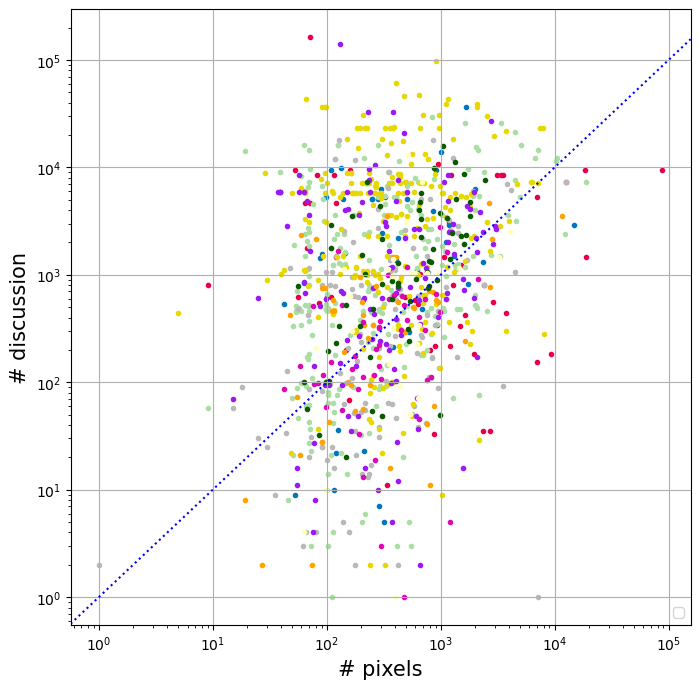

In [98]:
plot_by_category(X_lst, Y_lst, "", colors)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


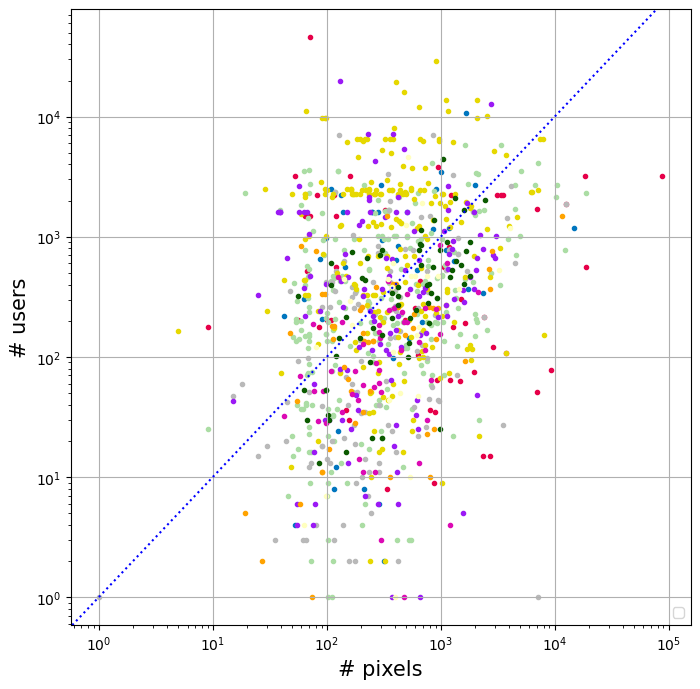

In [101]:
user_dict = categorize_project_stat(u_per_proj,category_subreddit,subr_id)
X_lst, Y_lst = batch_Create_Array(pixels_dict, user_dict)
plot_by_category(X_lst, Y_lst, "", colors)

In [245]:
X_17_user, Y_17_user = Create_Array(pixels_proj_17, u_per_proj)

1018


In [246]:
len(X_17_user)

1010

In [169]:
from matplotlib.ticker import ScalarFormatter
#Inverse cumulative density funcition

%matplotlib inline

def plot_updates_vs_pixels(X, Y, output_file_name, col, lab):
    white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)
#    xy = np.vstack([X,Y])
#    z = gaussian_kde(xy)(xy)
#    idx = z.argsort()
#    x, y, z = X[idx], Y[idx], z[idx]
    plt.clf()
    fig = plt.figure(figsize=(4,3))
    ax = plt.subplot(111,projection='scatter_density')    
    density = ax.scatter_density(X, Y, cmap=white_viridis)
    fig.colorbar(density, label='Number of points per pixel')
    logx = np.log(X)
    logy = np.log(Y)
    coeffs = np.polyfit(logx,logy,1)
    poly = np.poly1d(coeffs)
    yfit = lambda X: np.exp(poly(np.log(X)))
    la = r"$y = e^{%s} x^{%s}$" % (round(coeffs[1],2), round(coeffs[0], 2))
#     plt.loglog(np.unique(X),yfit(np.unique(X)), color='red', label = la) 
    plt.scatter(X, Y, marker='.', s=5)
    ax.axline((1, 1),  (10, 10), color="blue", linestyle=":")

    ax.set_ylabel('# discussion', fontsize=15)
    #ax.tick_params(labelsize=10)
    ax.set_xlabel('# pixels', fontsize=15)
    ax.set_xscale('log')
    ax.set_yscale('log')
#     ax.set_xlim([1,10**7])
#     ax.set_ylim([1,10**2])
#     ax.set_xticks(logx)
#     ax.set_aspect('equal', 'box')
    ax.legend(loc = 'lower right')
    ax.grid()
#     plt.axis('square')
    
#     plt.savefig(output_file_name, dpi=300, bbox_inches='tight')
#     return coeffs[0]


In [12]:
def updates_per_hour(file):
    total_hours = 89
    update_hour  = np.zeros(total_hours)
    with open(file, "r") as f:
        reader = csv.reader(f, delimiter=',')
        next(reader)
        for line in reader:
            t = elapsed_time(int(line[0]) / 1000)
            update_hour[t] += 1
    return update_hour #/ sum(update_hour)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1018


<Figure size 640x480 with 0 Axes>

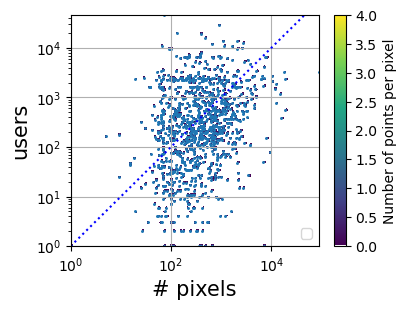

In [248]:
X_17_user, Y_17_user = Create_Array(pixels_proj_17, u_per_proj)
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1014


<Figure size 640x480 with 0 Axes>

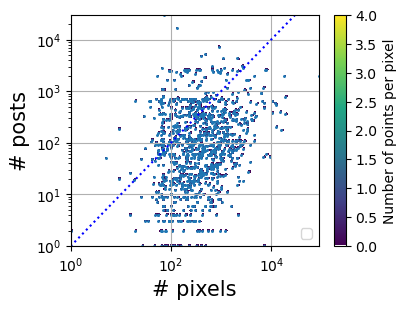

In [251]:
X_17_user, Y_17_user = Create_Array(pixels_proj_17, posts_per_proj)
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1018


<Figure size 640x480 with 0 Axes>

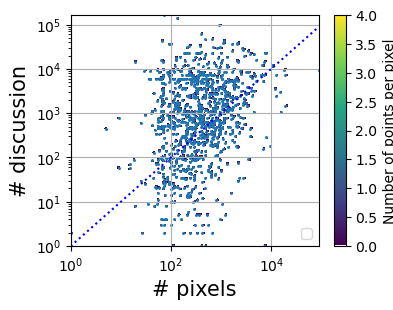

In [253]:
X_17_user, Y_17_user = Create_Array(pixels_proj_17, comm_post_per_proj)
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

# Splitting posts by time

In [8]:
start_utc = 1490918688
end_utc = 1491238734
total_hours = 89
import matplotlib.ticker as mtick


In [11]:
# c_p_hour = comment_posts_per_hour(RC_path+"RS_successful", RC_path+"RC_successful")
updates_hour = updates_per_hour("/scratch/yw180/place/data/tile_placements.csv")

TypeError: elapsed_time() missing 2 required positional arguments: 'start_time' and 'end_time'

In [95]:
# c_p_hour /= sum(c_p_hour)
updates_hour /= sum(updates_hour)
# c_p_hour = c_p_hour * 100
updates_hour = updates_hour * 100

In [162]:
with open("/scratch/yw180/reddit_thread/2017_event.pkl", "rb") as input_file:
    event_17 = pickle.load(input_file)   

In [163]:
event_17 = {(key - 720):event_17[key] for key in event_17.keys()}

In [164]:
c_p_hour = np.array([event_17[key] for key in event_17.keys()])
# c_p_hour = c_p_hour / sum(c_p_hour)
# c_p_hour = c_p_hour * 100

Text(0.5, 0, 'time')

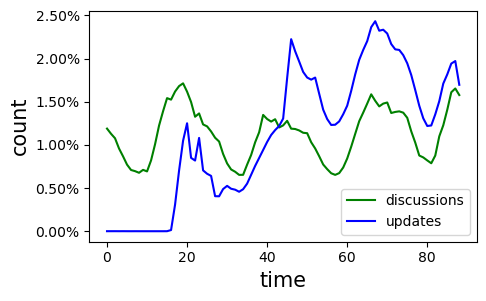

In [106]:
fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
X = np.arange(0, 89)
plt.plot(X, c_p_hour, c= 'g', label = "discussions")
plt.plot(X, updates_hour, c='b', label="updates")
ax.set_ylabel('count', fontsize=15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc = 'lower right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

# Load Data

## 2017

In [13]:
def elapsed_time(t, start_time):
    start_utc = 1648835050
    end_utc = 1649126650
    return math.floor((t - start_time) / 3600)
def updates_per_hour(file, year, start_time, total_hours):
    update_hour  = np.zeros(total_hours)
    with open(file, "r") as f:
        reader = csv.reader(f, delimiter=',')
        next(reader)
        for line in reader:
            if year == 2017:
                t = elapsed_time(int(line[0]) / 1000, start_time)
            else:
                t = elapsed_time(int(line[0]), start_time)
            update_hour[t] += 1
    return update_hour 

In [14]:
import pandas as pd
start_time_17 = 1490918688
total_hours_17 = 89
updates_hour = updates_per_hour("/scratch/yw180/place/data/tile_placements.csv", 2017, start_time_17, total_hours_17)
with open("/scratch/yw180/reddit_thread/2017_event.pkl", "rb") as input_file:
    event_17 = pickle.load(input_file)   
event_17 = {(key - 720):event_17[key] for key in event_17.keys()}
c_p_hour = np.array([event_17[key] for key in event_17.keys()])
X = np.arange(1, 90)
df = pd.DataFrame(list(zip(X, c_p_hour, updates_hour)), columns=['Time', 'Discussions', 'Updates'])


NameError: name 'pickle' is not defined

In [183]:
df_discussion = df[['Discussions']]
df_update = df[['Updates']]

# 2022

In [51]:
import pickle
with open("/scratch/yw180/reddit_thread_2022_event.pkl", "rb") as input_file:
    event_22 = pickle.load(input_file)   

In [23]:
from datetime import datetime

def calculate_hour_difference(time, format_string="%Y-%m-%d %H:%M:%S.%f %Z"):
    start_time = "2022-04-01 12:44:10.315 UTC"
    formats = ["%Y-%m-%d %H:%M:%S.%f %Z", "%Y-%m-%d %H:%M:%S %Z"]
    datetime_object1 = datetime.strptime(start_time, formats[0])
    for fmt in formats:
        try:
            return math.floor(abs(datetime.strptime(time, fmt) - datetime_object1).total_seconds()/3600)
        except ValueError:
            continue
    return None

In [41]:
def elapsed_time(t):
    start_utc = 1648835050
    end_utc = 1649126650
    return math.floor((t - start_utc) / 3600)
def updates_per_hour(file):
    total_hours = 82
    update_hour  = np.zeros(total_hours)
    with open(file, "r") as f:
        reader = csv.reader(f, delimiter=',')
        next(reader)
        for line in reader:
            t = elapsed_time(int(line[0]))
            update_hour[t] += 1
    return update_hour 

In [42]:
proj_file_22 = "/home/yw180/place/data_2022/sorted_tile_placements.csv"
update_hour_22 = updates_per_hour(proj_file_22)

In [55]:
import pandas as pd
c_p_hour = np.array([event_22[key] for key in event_22.keys()])
X = np.arange(1, 83)
df = pd.DataFrame(list(zip(X, c_p_hour, update_hour_22)), columns=['Time', 'Discussions', 'Updates'])

In [59]:
df['Discussions_percent'] = (df['Discussions']   / df['Discussions'].sum()) * 100
df['Updates_percent'] = (df['Updates']   / df['Updates'].sum()) * 100

Text(0.5, 0, 'time')

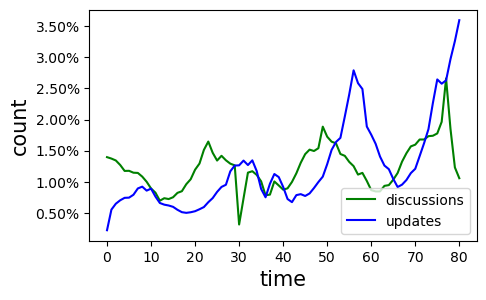

In [63]:
fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
X = np.arange(0, 81)
plt.plot(X, df['Discussions_percent'], c= 'g', label = "discussions")
plt.plot(X, df['Updates_percent'], c='b', label="updates")
ax.set_ylabel('count', fontsize=15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc = 'lower right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

In [66]:
df_discussion = df['Discussions']
df_update = df['Updates']

## 2023

In [368]:
import pickle
with open("/scratch/yw180/reddit_thread_2023_event.pkl", "rb") as input_file:
    event_23 = pickle.load(input_file) 
del event_23[599]

In [356]:
def elapsed_time(t):
    start_utc = 1689876026
    end_utc = 1690326100
    return math.floor((t - start_utc) / 3600)
def updates_per_hour(file):
    total_hours = 125
    update_hour  = np.zeros(total_hours)
    with open(file, "r") as f:
        reader = csv.reader(f, delimiter=',')
        next(reader)
        for line in reader:
            t = elapsed_time(int(line[0]))
            if t == 125:
                update_hour[t - 1] += 1
            else:
                update_hour[t] += 1
    return update_hour 

In [351]:
proj_file_23 = "/home/yw180/place/data_2023/sorted_tile_placements_coord.csv"
update_hour_23 = updates_per_hour(proj_file_23)

In [369]:
import pandas as pd
c_p_hour = np.array([event_23[key] for key in event_23.keys()])
X = np.arange(1, 126)
df = pd.DataFrame(list(zip(X, c_p_hour, update_hour_23)), columns=['Time', 'Discussions', 'Updates'])

In [370]:
df['Discussions_percent'] = (df['Discussions']   / df['Discussions'].sum()) * 100
df['Updates_percent'] = (df['Updates']   / df['Updates'].sum()) * 100

Text(0.5, 0, 'time')

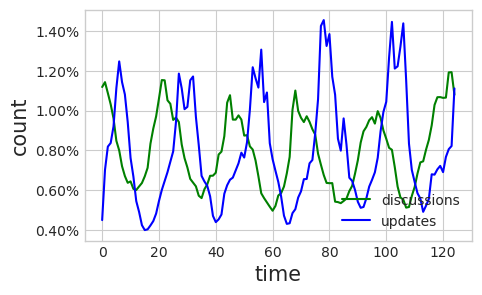

In [372]:
fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
X = np.arange(0, 125)
plt.plot(X, df['Discussions_percent'], c= 'g', label = "discussions")
plt.plot(X, df['Updates_percent'], c='b', label="updates")
ax.set_ylabel('count', fontsize=15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc = 'lower right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

In [376]:
df_discussion = df['Discussions']
df_update = df['Updates']

# Find the best time period using FFT

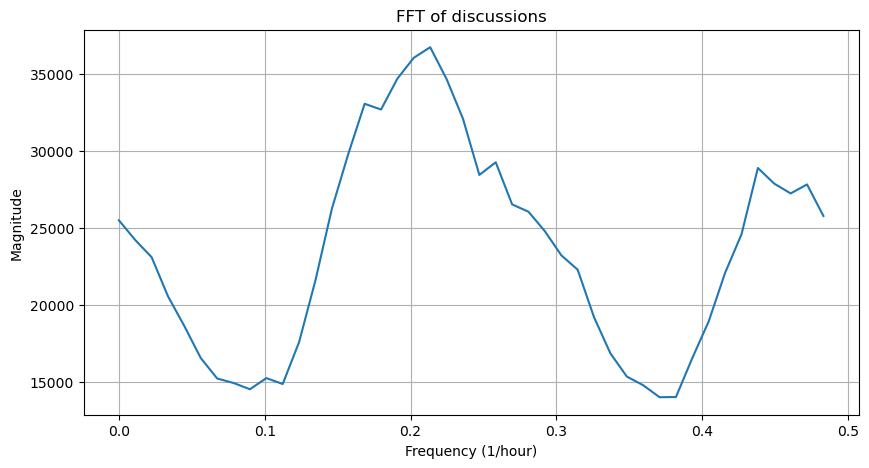

In [195]:
yf = fft(df_discussion)
N = len(df_discussion)
xf = fftfreq(len(df_discussion), 1) 
xf = xf[:N//2]
yf = np.abs(yf[:N//2]) 
plt.figure(figsize=(10,5))
plt.plot(xf, yf)
plt.xlabel("Frequency (1/hour)")
plt.ylabel("Magnitude")
plt.title("FFT of discussions")
plt.grid()
plt.show()

In [196]:
idx = 0
for i in range(0, len(yf)):
    if yf[i] == max(yf):
        idx = i
print(xf[idx])

0.21348314606741572


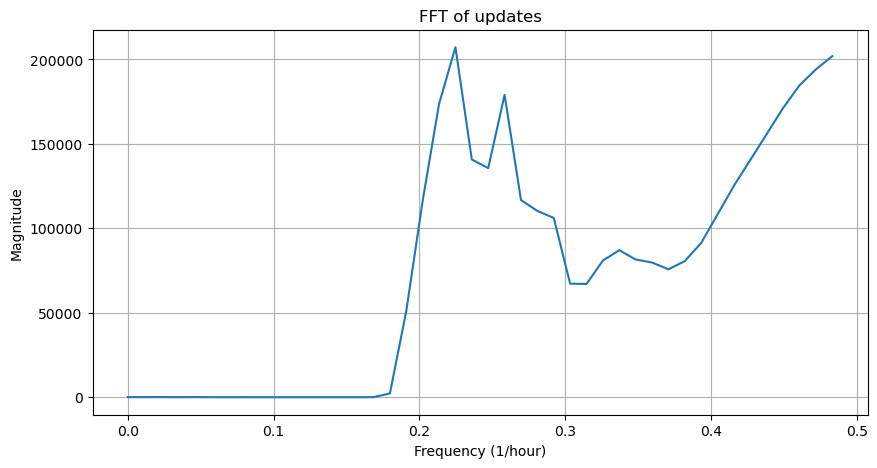

In [185]:
from scipy.fftpack import fft, fftfreq
yf = fft(df_update)
N = len(df_discussion)
xf = fftfreq(len(df_discussion), 1) 
xf = xf[:N//2]
yf = np.abs(yf[:N//2]) 
plt.figure(figsize=(10,5))
plt.plot(xf, yf)
plt.xlabel("Frequency (1/hour)")
plt.ylabel("Magnitude")
plt.title("FFT of updates")
plt.grid()
plt.show()

In [194]:
idx = 0
for i in range(0, len(yf)):
    if yf[i] == max(yf):
        idx = i
print(xf[idx])

0.2247191011235955


## 2022

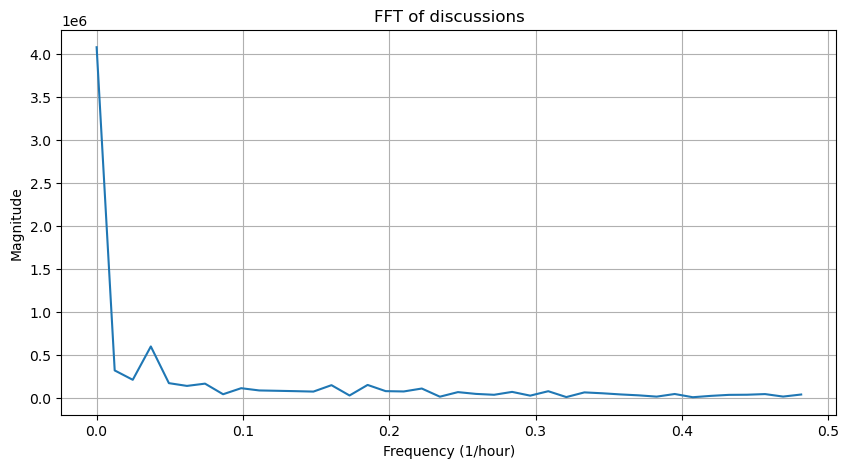

In [74]:

df_discussion = np.array(df_discussion.values)
yf = fft(df_discussion)
N = len(df_discussion)
xf = fftfreq(len(df_discussion), 1) 
xf = xf[:N//2]
yf = np.abs(yf[:N//2]) 
plt.figure(figsize=(10,5))
plt.plot(xf, yf)
plt.xlabel("Frequency (1/hour)")
plt.ylabel("Magnitude")
plt.title("FFT of discussions")
plt.grid()
plt.show()

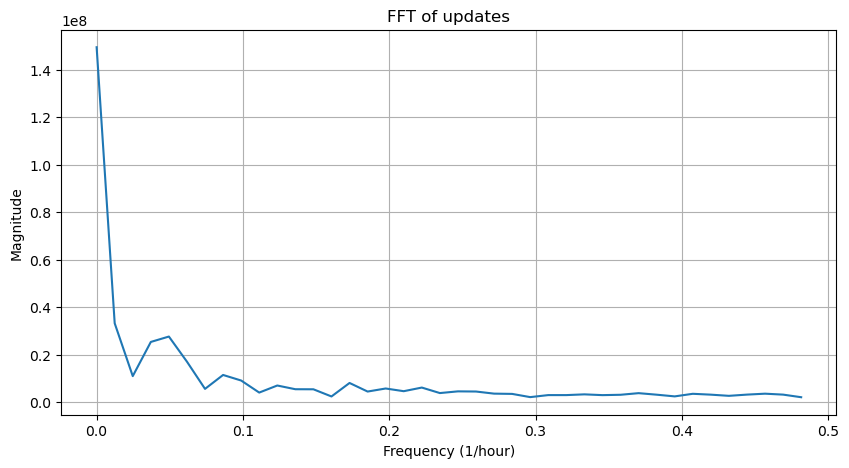

In [73]:
df_update = np.array(df_update.values)
yf = fft(df_update)
N = len(df_update)
xf = fftfreq(len(df_discussion), 1) 
xf = xf[:N//2]
yf = np.abs(yf[:N//2]) 
plt.figure(figsize=(10,5))
plt.plot(xf, yf)
plt.xlabel("Frequency (1/hour)")
plt.ylabel("Magnitude")
plt.title("FFT of updates")
plt.grid()
plt.show()

## 2023

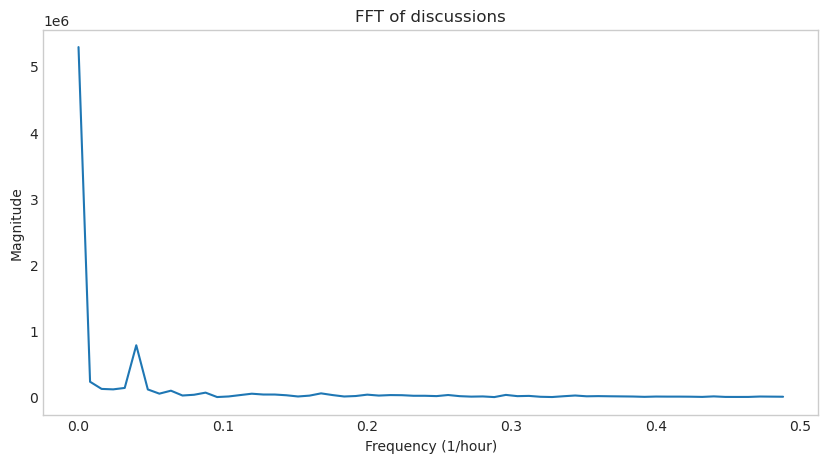

In [377]:

df_discussion = np.array(df_discussion.values)
yf = fft(df_discussion)
N = len(df_discussion)
xf = fftfreq(len(df_discussion), 1) 
xf = xf[:N//2]
yf = np.abs(yf[:N//2]) 
plt.figure(figsize=(10,5))
plt.plot(xf, yf)
plt.xlabel("Frequency (1/hour)")
plt.ylabel("Magnitude")
plt.title("FFT of discussions")
plt.grid()
plt.show()

In [378]:
len(df_discussion)

125

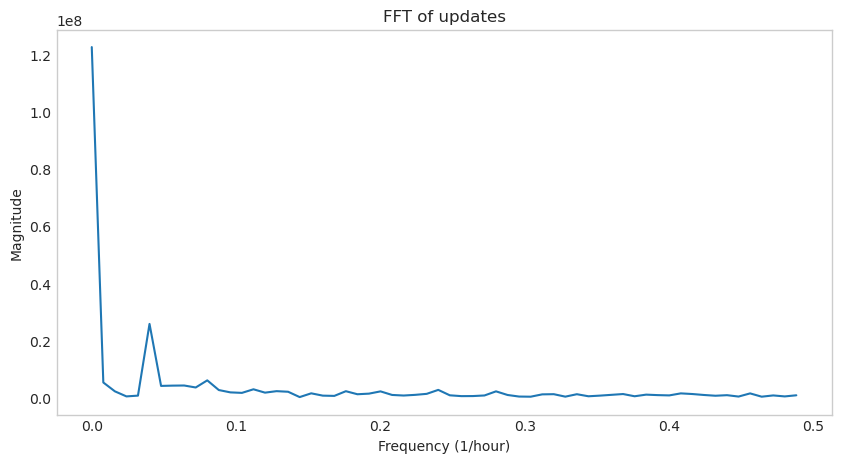

In [379]:
df_update = np.array(df_update.values)
yf = fft(df_update)
N = len(df_update)
xf = fftfreq(len(df_discussion), 1) 
xf = xf[:N//2]
yf = np.abs(yf[:N//2]) 
plt.figure(figsize=(10,5))
plt.plot(xf, yf)
plt.xlabel("Frequency (1/hour)")
plt.ylabel("Magnitude")
plt.title("FFT of updates")
plt.grid()
plt.show()

# Seasonal Decomposition, period = 4 hours

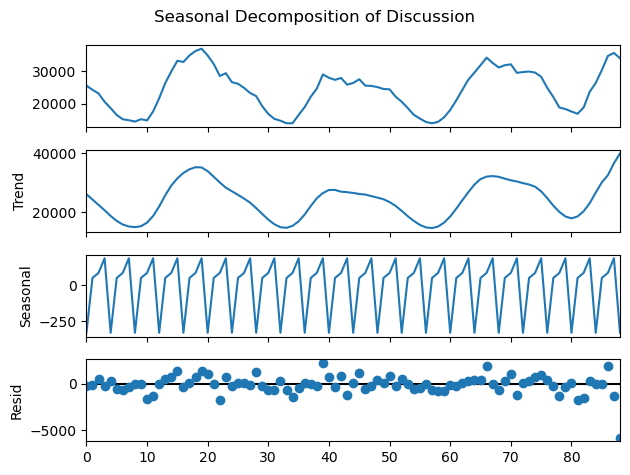

In [349]:
result = seasonal_decompose(df_discussion, model='additivie', period= 4, extrapolate_trend='freq')
result.plot()
plt.suptitle('Seasonal Decomposition of Discussion')
plt.tight_layout()
plt.show()

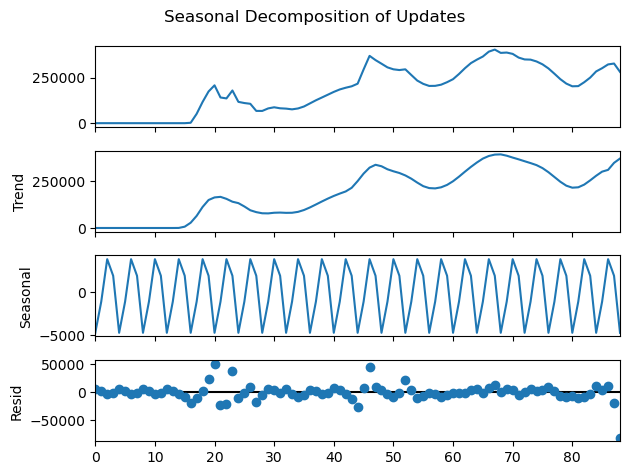

In [350]:
result = seasonal_decompose(df_update, model='additivie', period= 4, extrapolate_trend='freq')
result.plot()
plt.suptitle('Seasonal Decomposition of Updates')
plt.tight_layout()
plt.show()

## 2022

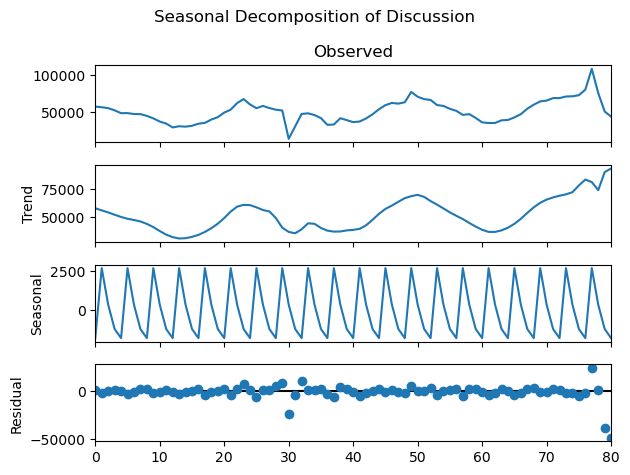

In [86]:
result = seasonal_decompose(df_discussion, model='additivie', period= 4, extrapolate_trend='freq')
result.plot()
plt.suptitle('Seasonal Decomposition of Discussion')
plt.tight_layout()
plt.show()

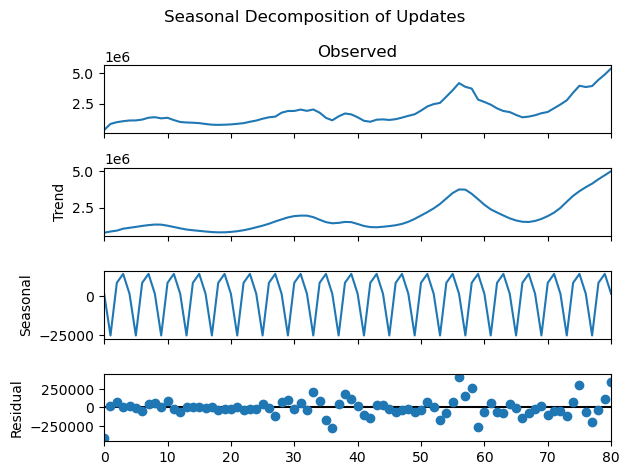

In [85]:
result = seasonal_decompose(df_update, model='additivie', period= 4, extrapolate_trend='freq')
result.plot()
plt.suptitle('Seasonal Decomposition of Updates')
plt.tight_layout()
plt.show()

## 2023

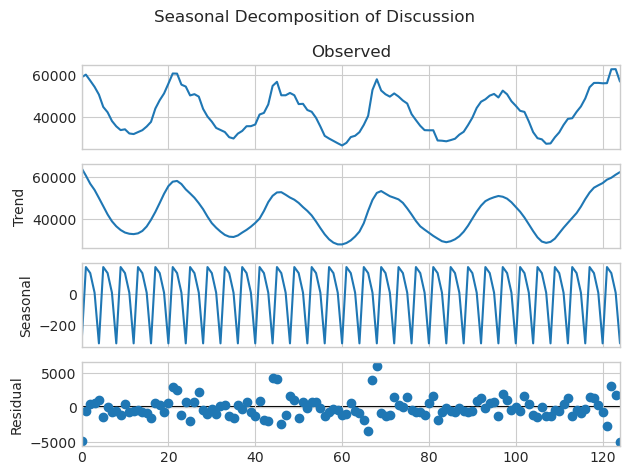

In [387]:
result = seasonal_decompose(df_discussion, model='additivie', period= 4, extrapolate_trend='freq')
result.plot()
plt.suptitle('Seasonal Decomposition of Discussion')
plt.tight_layout()
plt.show()

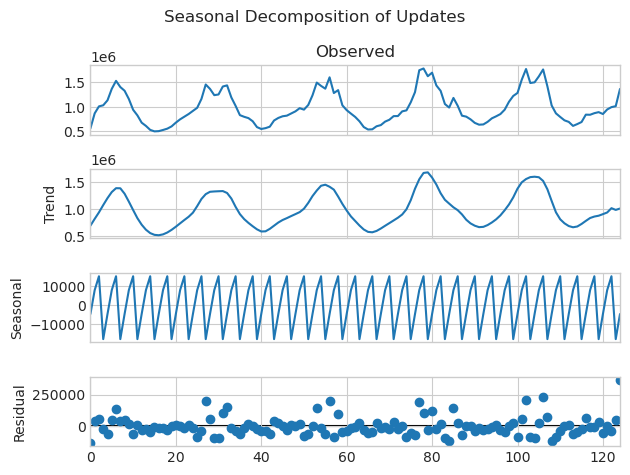

In [388]:
result = seasonal_decompose(df_update, model='additivie', period= 4, extrapolate_trend='freq')
result.plot()
plt.suptitle('Seasonal Decomposition of Updates')
plt.tight_layout()
plt.show()

# Simple check for correlation using .corr()

In [87]:
result = df['Discussions'].corr(df['Updates'])
print(result)

0.34674762842800544


# Ordinary Linear Square (OLS)

$y_t$ is the # of updates, $x_t$ is the # of discussions, $\delta(\cdot)$ is the delta function correlated to seasonality

$y_t = \beta_0 + \beta_1(x_t) + \beta_2(\delta(t_0)) + \ldots + \beta_7(\delta(t_5))$


In [275]:
day_bool = list()
for index, row in df.iterrows():
    if row["Time"] <= 5:
        day_bool.append(0)
    elif row["Time"] > 5 and ((row["Time"] - 6) // 12) % 2 == 0:
        day_bool.append(1)
    else:
        day_bool.append(0)

In [277]:
df["Day"] = day_bool

In [264]:
# # Create time dummies, 4 time steps per group
# df['time_group'] = (df['Time'] - 1) // 12 + 1  # Groups: 1-4 -> 1, 5-8 -> 2, etc.

# # Creating dummy variables
# df = pd.get_dummies(df, columns=['time_group'], prefix='time')


In [282]:
df

,Time,Discussions,Updates,Day
0,1,25491,48.0,0
1,2,24207,59.0,0
2,3,23091,80.0,0
3,4,20549,23.0,0
4,5,18609,79.0,0
...,...,...,...,...
84,85,26319,283325.0,1
85,86,30186,300998.0,1
86,87,34518,321684.0,1
87,88,35457,326551.0,1


In [266]:
df.loc[:, df.columns.str.startswith('time_')] = df.loc[:, df.columns.str.startswith('time_')].astype(int)

# Relationship with 12 hour period

# Split by CST: Start time is March 31st 7:00 pm CST

In [279]:
import statsmodels.api as sm
X = df[['Discussions', "Day"]]# + [col for col in df.columns if col.startswith('time_')]] 
X = sm.add_constant(X)
X = X.apply(pd.to_numeric, errors='coerce')


In [280]:
y = df['Updates']

In [281]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Updates   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     8.238
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           0.000533
Time:                        18:44:55   Log-Likelihood:                -1164.3
No. Observations:                  89   AIC:                             2335.
Df Residuals:                      86   BIC:                             2342.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         3.32e+04   6.46e+04      0.514      

# Split by 4-hour window

In [454]:
df = df[["Time", "Discussions", "Updates"]]

In [455]:
time_list = [list() for i in range(0, 6)]
for index, row in df.iterrows():
    val = ((row["Time"] - 1) // 4) % 6
    for i in range(0, 6):
        if i == val:
            time_list[i].append(1)
        else:
            time_list[i].append(0)


In [456]:
df['Time_0'] = time_list[0]
df['Time_1'] = time_list[1]
df['Time_2'] = time_list[2]
df['Time_3'] = time_list[3]
df['Time_4'] = time_list[4]
df['Time_5'] = time_list[5]

/tmp/ipykernel_2328348/286871342.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_0'] = time_list[0]
/tmp/ipykernel_2328348/286871342.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_1'] = time_list[1]
/tmp/ipykernel_2328348/286871342.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

In [457]:
X = df[['Updates','Time_0','Time_1','Time_2','Time_3','Time_4','Time_5']] 
X = sm.add_constant(X)
y = df['Discussions']

In [458]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Discussions   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.727
Method:                 Least Squares   F-statistic:                     40.04
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           2.18e-22
Time:                        12:45:30   Log-Likelihood:                -846.53
No. Observations:                  89   AIC:                             1707.
Df Residuals:                      82   BIC:                             1724.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.992e+04    592.983     33.597      0.0

# Use the first 60 entries to predict the last 29 entries

In [459]:
df_train = df.head(60)
df_test = df.tail(29)

In [460]:
X = df_train[['Updates','Time_0','Time_1','Time_2','Time_3','Time_4','Time_5']] 
X = sm.add_constant(X)
y = df_train['Discussions']

In [461]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Discussions   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     37.79
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           1.87e-17
Time:                        12:45:44   Log-Likelihood:                -560.98
No. Observations:                  60   AIC:                             1136.
Df Residuals:                      53   BIC:                             1151.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.082e+04    556.067     37.447      0.0

In [464]:
X_test = df_test[['Updates','Time_0','Time_1','Time_2','Time_3','Time_4','Time_5']] 

X_test = sm.add_constant(X_test)
y_test = df_test['Discussions'].to_list()

In [465]:
predicted_value = model.predict(X_test)
predicted_value = predicted_value.to_list()

In [466]:
# MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, predicted_value)

# Compute Variance of y_true
variance = np.var(y_test)

# Compute NMSE
nmse = mse / variance

print(f"Normalized MSE: {nmse:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


Normalized MSE: 0.8184
Mean Squared Error: 26750021.0735


# Check if the series are stationary

# The updates sereis is not, but the discussion is

In [88]:
from statsmodels.tsa.stattools import adfuller

In [410]:
result = adfuller(df['Discussions'])
print(f'Test Statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'critical_values: {result[4]}')
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")

Test Statistics: -5.016660253291221
p-value: 2.05684793344482e-05
critical_values: {'1%': -3.5097356063504983, '5%': -2.8961947486260944, '10%': -2.5852576124567475}
Series is stationary


In [411]:
result = adfuller(df['Updates'])
print(f'Test Statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'critical_values: {result[4]}')
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")

Test Statistics: -1.9181135988260847
p-value: 0.32358846581418393
critical_values: {'1%': -3.5117123057187376, '5%': -2.8970475206326833, '10%': -2.5857126912469153}
Series is not stationary


## 2022

In [89]:
result = adfuller(df['Discussions'])
print(f'Test Statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'critical_values: {result[4]}')
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")

Test Statistics: -3.8049318648706687
p-value: 0.0028572567160426695
critical_values: {'1%': -3.5219803175527606, '5%': -2.9014701097664504, '10%': -2.58807215485756}
Series is stationary


In [90]:
result = adfuller(df['Updates'])
print(f'Test Statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'critical_values: {result[4]}')
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")

Test Statistics: -0.14466251102759048
p-value: 0.944804242093418
critical_values: {'1%': -3.5159766913976376, '5%': -2.898885703483903, '10%': -2.5866935058484217}
Series is not stationary


## 2023

In [389]:
result = adfuller(df['Discussions'])
print(f'Test Statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'critical_values: {result[4]}')
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")

Test Statistics: -5.893279382957002
p-value: 2.8906461314006206e-07
critical_values: {'1%': -3.4880216384691867, '5%': -2.8867966864160075, '10%': -2.5802408234244947}
Series is stationary


In [390]:
result = adfuller(df['Updates'])
print(f'Test Statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'critical_values: {result[4]}')
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")

Test Statistics: -5.968131302572421
p-value: 1.965356590914805e-07
critical_values: {'1%': -3.4865346059036564, '5%': -2.8861509858476264, '10%': -2.579896092790057}
Series is stationary


# Making both sereis stationary + Granger Causality

In [438]:
df_stationary = df[['Time','Updates','Discussions']]
df_stationary['Discussion_diff'] = df_stationary['Discussions'].diff(4)
df_stationary['Updates_diff'] = df_stationary['Updates'].diff(4)
df_stationary = df_stationary.dropna()

/tmp/ipykernel_2328348/2719881571.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stationary['Discussion_diff'] = df_stationary['Discussions'].diff(4)
/tmp/ipykernel_2328348/2719881571.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stationary['Updates_diff'] = df_stationary['Updates'].diff(4)


## 2022

In [106]:
df_stationary = df[['Time','Updates','Discussions']]
df_stationary['Discussion_diff'] = df_stationary['Discussions'].diff(4)
df_stationary['Updates_diff'] = df_stationary['Updates'].diff(4)
df_stationary = df_stationary.dropna()

/tmp/ipykernel_2714102/2719881571.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stationary['Discussion_diff'] = df_stationary['Discussions'].diff(4)


# Pearson Correlation after differencing

In [468]:
result = df_stationary['Discussion_diff'].corr(df_stationary['Updates_diff'])
print(result)

0.5821300436188994


In [101]:
# 2022
result = df_stationary['Discussion_diff'].corr(df_stationary['Updates_diff'])
print(result)

-0.10527046013746964


Text(0.5, 0, 'time')

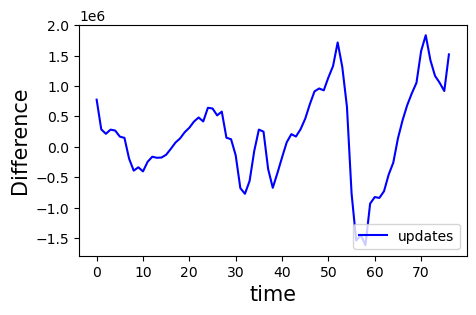

In [94]:
# Detrending by differencing
hour_in_day = 24
diff_discussion = list()
diff_update = list()

fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
X = np.arange(0,len(df_stationary['Updates_diff']))
plt.plot(X, df_stationary['Updates_diff'], c='b', label="updates")
ax.set_ylabel('Difference', fontsize=15)
ax.legend(loc = 'lower right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

Text(0.5, 0, 'time')

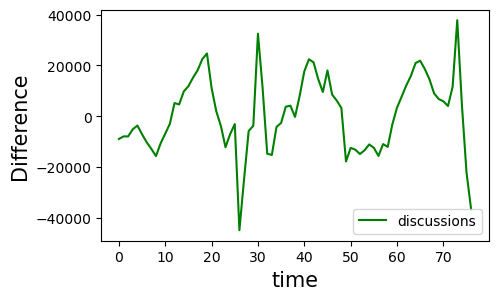

In [95]:
# Detrending by differencing
hour_in_day = 24
diff_discussion = list()
diff_update = list()

fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
X = np.arange(0,len(df_stationary['Discussion_diff']))
plt.plot(X, df_stationary['Discussion_diff'], c='g', label="discussions")
ax.set_ylabel('Difference', fontsize=15)
ax.legend(loc = 'lower right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

In [102]:
result = adfuller(df_stationary['Discussion_diff'])
print(f'Test Statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'critical_values: {result[4]}')
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")

Test Statistics: -6.911040085276727
p-value: 1.2122152594274034e-09
critical_values: {'1%': -3.517113604831504, '5%': -2.8993754262546574, '10%': -2.5869547797501644}
Series is stationary


In [103]:
result = adfuller(df_stationary['Updates_diff'])
print(f'Test Statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'critical_values: {result[4]}')
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")

Test Statistics: -4.642637235343285
p-value: 0.00010770815470540236
critical_values: {'1%': -3.5159766913976376, '5%': -2.898885703483903, '10%': -2.5866935058484217}
Series is stationary


## 2022

In [96]:
result = adfuller(df_stationary['Discussion_diff'])
print(f'Test Statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'critical_values: {result[4]}')
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")

Test Statistics: -4.201581454388252
p-value: 0.0006548504806301624
critical_values: {'1%': -3.5352168748293127, '5%': -2.9071540828402367, '10%': -2.5911025443786984}
Series is stationary


In [97]:
result = adfuller(df_stationary['Updates_diff'])
print(f'Test Statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'critical_values: {result[4]}')
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")

Test Statistics: -3.7613670124527396
p-value: 0.0033282572864373585
critical_values: {'1%': -3.5352168748293127, '5%': -2.9071540828402367, '10%': -2.5911025443786984}
Series is stationary


## Granger's Causality tests whether one time series can be used to predict the other

Answer is no in this case

In [441]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag = 4 # Maximum number of lags to test
test_result = grangercausalitytests(df_stationary[['Discussion_diff', 'Updates_diff']], maxlag=maxlag, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.5918  , p=0.0616  , df_denom=81, df_num=1
ssr based chi2 test:   chi2=3.7248  , p=0.0536  , df=1
likelihood ratio test: chi2=3.6446  , p=0.0563  , df=1
parameter F test:         F=3.5918  , p=0.0616  , df_denom=81, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1888  , p=0.8284  , df_denom=78, df_num=2
ssr based chi2 test:   chi2=0.4017  , p=0.8180  , df=2
likelihood ratio test: chi2=0.4008  , p=0.8184  , df=2
parameter F test:         F=0.1888  , p=0.8284  , df_denom=78, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0313  , p=0.9925  , df_denom=75, df_num=3
ssr based chi2 test:   chi2=0.1028  , p=0.9915  , df=3
likelihood ratio test: chi2=0.1028  , p=0.9915  , df=3
parameter F test:         F=0.0313  , p=0.9925  , df_denom=75, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.1208  , p=0.9746  , df_d

/home/yw180/.conda/envs/yw180/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 2022

In [107]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag = 6 # Maximum number of lags to test
test_result = grangercausalitytests(df_stationary[['Discussion_diff', 'Updates_diff']], maxlag=maxlag, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.1189  , p=0.1498  , df_denom=73, df_num=1
ssr based chi2 test:   chi2=2.2059  , p=0.1375  , df=1
likelihood ratio test: chi2=2.1745  , p=0.1403  , df=1
parameter F test:         F=2.1189  , p=0.1498  , df_denom=73, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.1190  , p=0.0504  , df_denom=70, df_num=2
ssr based chi2 test:   chi2=6.6835  , p=0.0354  , df=2
likelihood ratio test: chi2=6.4023  , p=0.0407  , df=2
parameter F test:         F=3.1190  , p=0.0504  , df_denom=70, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.0933  , p=0.1093  , df_denom=67, df_num=3
ssr based chi2 test:   chi2=6.9361  , p=0.0740  , df=3
likelihood ratio test: chi2=6.6300  , p=0.0847  , df=3
parameter F test:         F=2.0933  , p=0.1093  , df_denom=67, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.1295  , p=0.0205  , df_d

/home/yw180/.conda/envs/yw180/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 2023

In [392]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag = 6 # Maximum number of lags to test
test_result = grangercausalitytests(df[['Discussions', 'Updates']], maxlag=maxlag, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=90.3542 , p=0.0000  , df_denom=121, df_num=1
ssr based chi2 test:   chi2=92.5944 , p=0.0000  , df=1
likelihood ratio test: chi2=69.1604 , p=0.0000  , df=1
parameter F test:         F=90.3542 , p=0.0000  , df_denom=121, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=19.7025 , p=0.0000  , df_denom=118, df_num=2
ssr based chi2 test:   chi2=41.0748 , p=0.0000  , df=2
likelihood ratio test: chi2=35.4410 , p=0.0000  , df=2
parameter F test:         F=19.7025 , p=0.0000  , df_denom=118, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=13.5756 , p=0.0000  , df_denom=115, df_num=3
ssr based chi2 test:   chi2=43.2057 , p=0.0000  , df=3
likelihood ratio test: chi2=36.9868 , p=0.0000  , df=3
parameter F test:         F=13.5756 , p=0.0000  , df_denom=115, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=6.3023  , p=0.0001  

/home/yw180/.conda/envs/yw180/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


# Broader Scale, March + April Data

In [58]:
import pickle
with open("/scratch/yw180/reddit_thread/2017_normal.pkl", "rb") as input_file:
    activity_17 = pickle.load(input_file)
    
with open("/scratch/yw180/reddit_thread/2017_event.pkl", "rb") as input_file:
    event_17 = pickle.load(input_file)    
    
combined_17 = dict()
for key in activity_17:
    combined_17[key] = activity_17[key]
for key in event_17:
    if key in combined_17:
        combined_17[key] += event_17[key]
    else:
        combined_17[key] = event_17[key]

In [59]:
X = np.arange(0, max(combined_17.keys()))
Y = np.zeros(len(X))
for i in range(0, len(Y)):
    if i in combined_17:
        Y[i] = combined_17[i]

In [60]:
df_combined = pd.DataFrame(list(zip(X, Y)), columns=['Time', 'Discussions'])


In [61]:
start_date = '2017-03-01 00:00:00'

# Create a date range with hourly frequency
date_range = pd.date_range(start=start_date, periods=1463, freq='H') # for 90 days



In [62]:
df_combined['Time'] = pd.to_datetime(date_range)

In [63]:
df_combined = pd.DataFrame(Y, index=date_range)


In [64]:
df_combined

,0
2017-03-01 00:00:00,27784.0
2017-03-01 01:00:00,29411.0
2017-03-01 02:00:00,31529.0
2017-03-01 03:00:00,31164.0
2017-03-01 04:00:00,25352.0
...,...
2017-04-30 18:00:00,27438.0
2017-04-30 19:00:00,29098.0
2017-04-30 20:00:00,29128.0
2017-04-30 21:00:00,28284.0


In [65]:
from adtk.data import validate_series
s_train = validate_series(df_combined)


[<Axes: >]

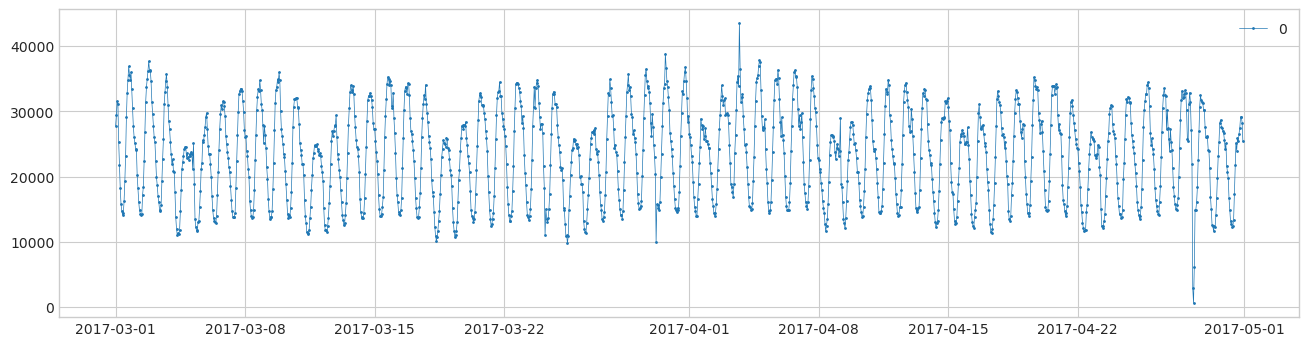

In [66]:
from adtk.visualization import plot
plot(s_train)

Text(0, 0.5, 'count')

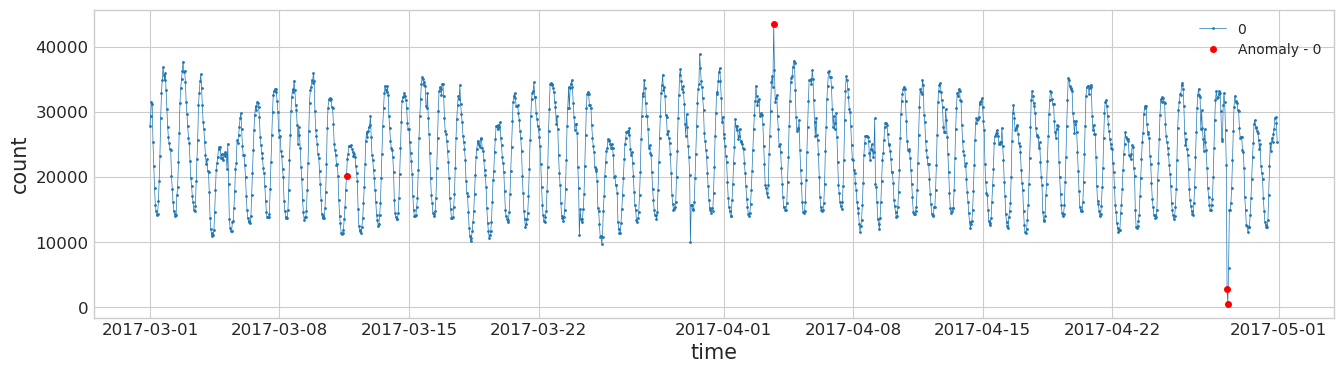

In [67]:
from adtk.detector import SeasonalAD
seasonal_ad = SeasonalAD()
anomalies = seasonal_ad.fit_detect(s_train)

plot(s_train, anomaly=anomalies, anomaly_color="red", anomaly_tag="marker")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("time", fontsize=15)
plt.ylabel("count", fontsize=15)

In [68]:
mask = (df_combined.index >= '2017-03-31 00:00:00') & (df_combined.index <= '2017-04-03 17:00:00')
filtered_df = df_combined[mask]

In [69]:
filtered_anomaly = df_combined[anomalies]

In [70]:
X_normal = np.array(df_combined.index)
Y_normal = np.array(df_combined[0])
X_anomaly = np.array(filtered_anomaly.index)
Y_anomaly = np.array(filtered_anomaly[0])
X_event = np.array(filtered_df.index)
Y_event = np.array(filtered_df[0])

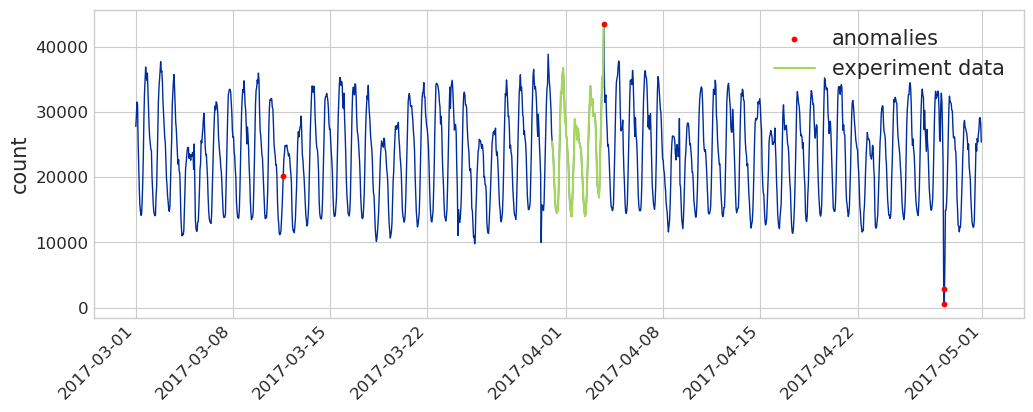

In [71]:
import matplotlib.pyplot as plt

# Example plot
fig, ax = plt.subplots(figsize=(12, 4))

# Plot normal data as line
ax.plot(X_normal, Y_normal, color='#002d9c', lw=1)

# Plot anomalies as red dots
ax.scatter(X_anomaly, Y_anomaly, color='red', label='anomalies', zorder=5, s = 10)

# Plot event data as another line (different color)
ax.plot(X_event, Y_event, label='experiment data', color='#a6d75b')

plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12)
plt.ylabel("count", fontsize=15)
plt.legend(loc='upper right',fontsize=15)

In [280]:
result_anomaly= anomalies.loc[anomalies[0]==True]

In [281]:
result_anomaly

,0
2017-03-11 15:00:00,True
2017-04-03 17:00:00,True
2017-04-28 05:00:00,True
2017-04-28 06:00:00,True


# 2022

In [72]:
with open("/scratch/yw180/reddit_thread_2022_normal.pkl", "rb") as input_file:
    activity_22 = pickle.load(input_file)
    
with open("/scratch/yw180/reddit_thread_2022_event.pkl", "rb") as input_file:
    event_22 = pickle.load(input_file)    
    
combined_22 = dict()
for key in activity_22:
    combined_22[key] = activity_22[key]
for key in event_22:
    if key in combined_22:
        combined_22[key] += event_22[key]
    else:
        combined_22[key] = event_22[key]

In [73]:
X = np.arange(0, max(combined_22.keys()))
Y = np.zeros(len(X))
for i in range(0, len(Y)):
    if i in combined_22:
        Y[i] = combined_22[i]

In [74]:
max(combined_22.keys())

1463

In [75]:
df_combined = pd.DataFrame(list(zip(X, Y)), columns=['Time', 'Discussions'])


In [76]:
start_date = '2022-03-01 00:00:00'

# Create a date range with hourly frequency
date_range = pd.date_range(start=start_date, periods=1463, freq='H') # for 90 days

df_combined['Time'] = pd.to_datetime(date_range)
df_combined = pd.DataFrame(Y, index=date_range)
df_combined.index = pd.to_datetime(df_combined.index)


In [77]:
df_combined

,0
2022-03-01 00:00:00,38075.0
2022-03-01 01:00:00,37268.0
2022-03-01 02:00:00,37216.0
2022-03-01 03:00:00,35525.0
2022-03-01 04:00:00,32448.0
...,...
2022-04-30 18:00:00,36983.0
2022-04-30 19:00:00,36220.0
2022-04-30 20:00:00,34781.0
2022-04-30 21:00:00,34770.0


In [78]:
from adtk.data import validate_series
s_train = validate_series(df_combined)


[<Axes: >]

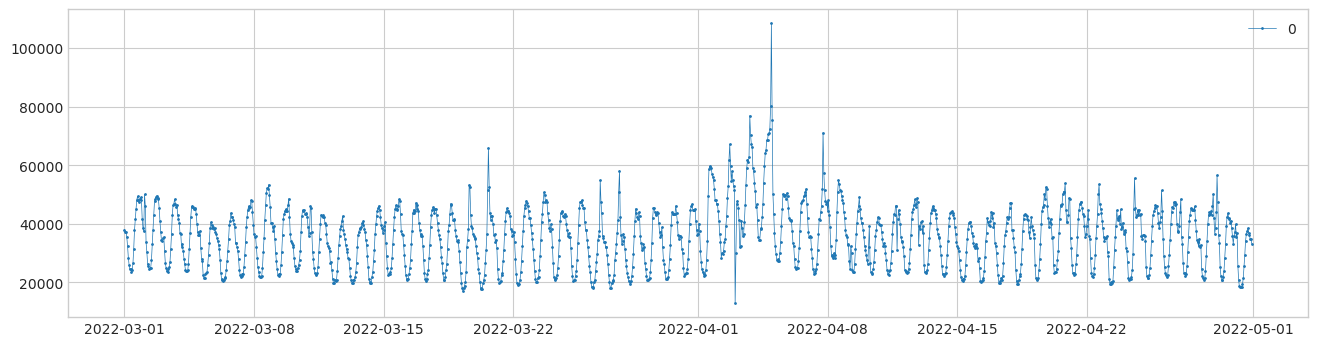

In [79]:
from adtk.visualization import plot
plot(s_train)

[<Axes: >]

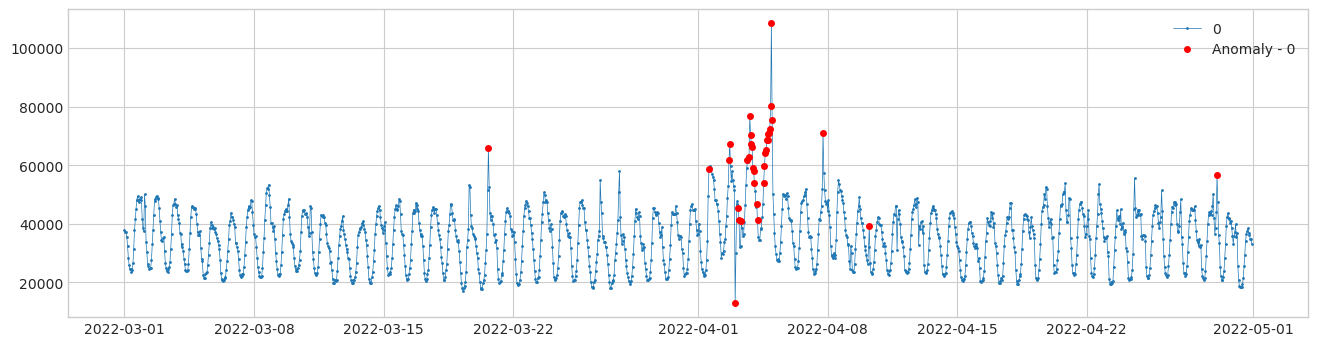

In [80]:
from adtk.detector import SeasonalAD
seasonal_ad = SeasonalAD()
anomalies = seasonal_ad.fit_detect(s_train)
plot(s_train, anomaly=anomalies, anomaly_color="red", anomaly_tag="marker")

In [81]:
mask = (df_combined.index >= '2022-04-01 13:00:00') & (df_combined.index <= '2022-04-04 23:00:00')
filtered_df = df_combined[mask]
filtered_anomaly = df_combined[anomalies]
X_normal = np.array(df_combined.index)
Y_normal = np.array(df_combined[0])
X_anomaly = np.array(filtered_anomaly.index)
Y_anomaly = np.array(filtered_anomaly[0])
X_event = np.array(filtered_df.index)
Y_event = np.array(filtered_df[0])

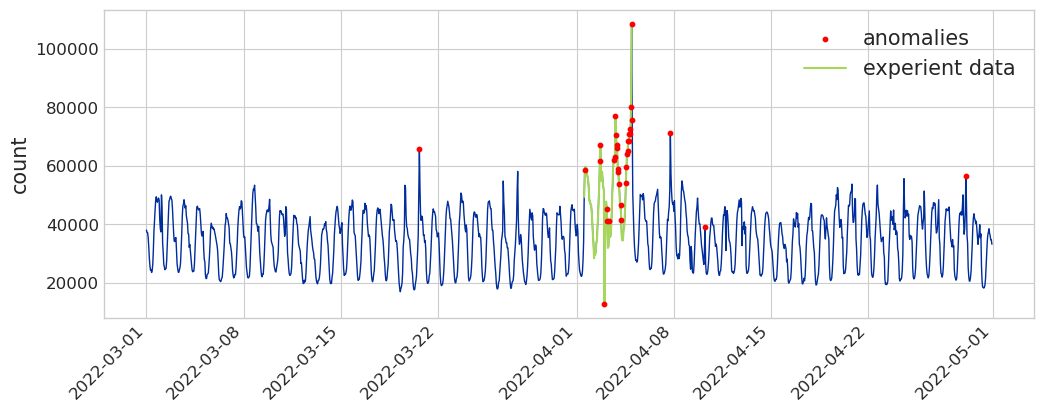

In [83]:
import matplotlib.pyplot as plt

# Example plot
fig, ax = plt.subplots(figsize=(12, 4))

# Plot normal data as line
ax.plot(X_normal, Y_normal, color='#002d9c', lw=1)

# Plot anomalies as red dots
ax.scatter(X_anomaly, Y_anomaly, color='red', label='anomalies', zorder=5, s = 10)

# Plot event data as another line (different color)
ax.plot(X_event, Y_event, label='experient data', color='#a6d75b')

plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12)
plt.ylabel("count", fontsize=15)
plt.legend(loc='upper right',fontsize=15)

In [159]:
result_anomaly= anomalies.loc[anomalies[0]==True]

In [121]:
# Event ends 4/4/2022
result_anomaly

,0
2022-03-20 16:00:00,True
2022-04-01 14:00:00,True
2022-04-02 16:00:00,True
2022-04-02 17:00:00,True
2022-04-03 00:00:00,True
2022-04-03 04:00:00,True
2022-04-03 05:00:00,True
2022-04-03 08:00:00,True
2022-04-03 16:00:00,True
2022-04-03 18:00:00,True


# 2023

In [84]:
with open("/scratch/yw180/reddit_thread_2023_normal.pkl", "rb") as input_file:
    activity_23 = pickle.load(input_file)
    
with open("/scratch/yw180/reddit_thread_2023_event.pkl", "rb") as input_file:
    event_23 = pickle.load(input_file)    
    
combined_23 = dict()
for key in activity_23:
    combined_23[key] = activity_23[key]
for key in event_23:
    if key in combined_23:
        combined_23[key] += event_23[key]
    else:
        combined_23[key] = event_23[key]

In [85]:
X = np.arange(0, max(combined_23.keys()))
Y = np.zeros(len(X))
for i in range(0, len(Y)):
    if i in combined_23:
        Y[i] = combined_23[i]

In [86]:
df_combined = pd.DataFrame(list(zip(X, Y)), columns=['Time', 'Discussions'])


In [87]:
start_date = '2023-07-01 00:00:00'

# Create a date range with hourly frequency
date_range = pd.date_range(start=start_date, periods=1487, freq='H') # for 90 days

df_combined['Time'] = pd.to_datetime(date_range)
df_combined = pd.DataFrame(Y, index=date_range)
df_combined.index = pd.to_datetime(df_combined.index)


In [88]:
from adtk.data import validate_series
s_train = validate_series(df_combined)


[<Axes: >]

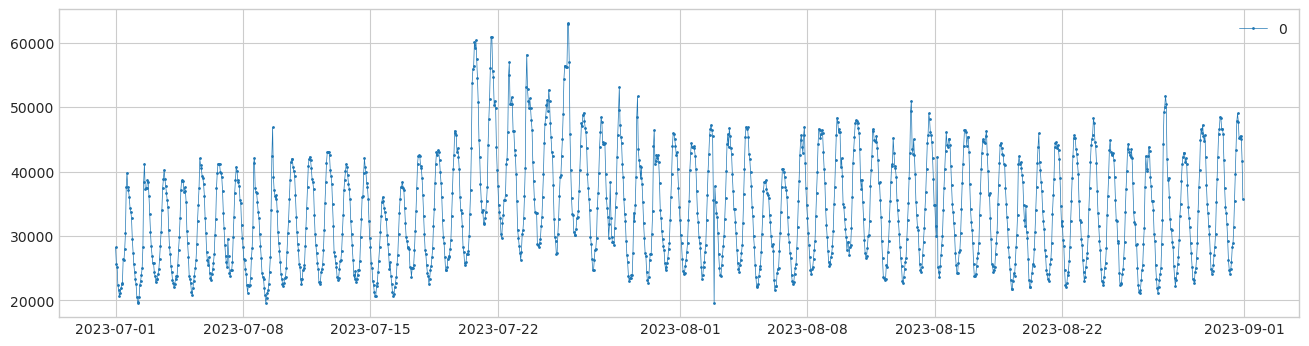

In [89]:
from adtk.visualization import plot
plot(s_train)

[<Axes: >]

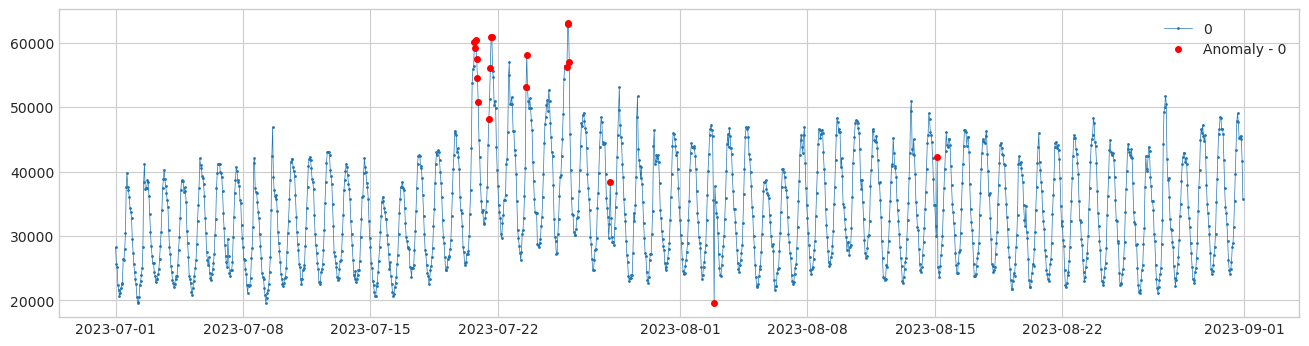

In [90]:
from adtk.detector import SeasonalAD
seasonal_ad = SeasonalAD()
anomalies = seasonal_ad.fit_detect(s_train)
plot(s_train, anomaly=anomalies, anomaly_color="red", anomaly_tag="marker")

In [91]:
mask = (df_combined.index >= '2023-07-20 13:00:00') & (df_combined.index <= '2023-07-25 18:00:00')
filtered_df = df_combined[mask]
filtered_anomaly = df_combined[anomalies]
X_normal = np.array(df_combined.index)
Y_normal = np.array(df_combined[0])
X_anomaly = np.array(filtered_anomaly.index)
Y_anomaly = np.array(filtered_anomaly[0])
X_event = np.array(filtered_df.index)
Y_event = np.array(filtered_df[0])

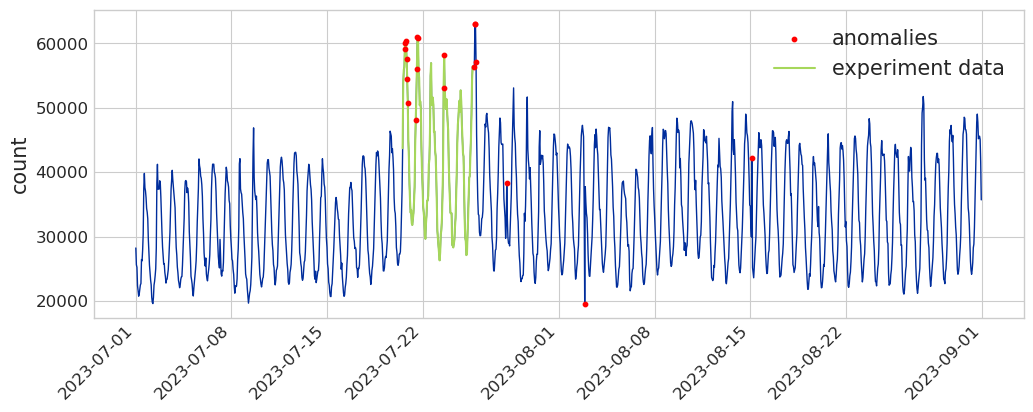

In [94]:
import matplotlib.pyplot as plt

# Example plot
fig, ax = plt.subplots(figsize=(12, 4))

# Plot normal data as line
ax.plot(X_normal, Y_normal, color='#002d9c', lw=1)

# Plot anomalies as red dots
ax.scatter(X_anomaly, Y_anomaly, color='red', label='anomalies', zorder=5, s = 10)

# Plot event data as another line (different color)
ax.plot(X_event, Y_event, label='experiment data', color='#a6d75b')

plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12)
plt.ylabel("count", fontsize=15)
plt.legend(loc='upper right',fontsize=15)

# r/place only curves

In [399]:
category = {}
with open(subreddit_category_path, "r") as file:
    reader = csv.reader(file)

    for line in reader:
        cate = line[1]
        subreddit = line[0]
        if cate == "":
            continue
        if cate.lower() not in category:
            category[cate.lower()] = {subreddit}
        else:
            category[cate.lower()].add(subreddit)
format_dict(category)

In [8]:
def comment_posts_per_hour_place_only(post_file, comment_file, category):
    total_hours = 89
    comment_posts = np.zeros(total_hours)
    with open(post_file, "r") as f:
        reader = csv.reader(f, delimiter=',')
        next(reader)
        for line in reader:
            t = elapsed_time(int(line[0]))
            subreddit = line[1]
            if subreddit in category["r/place only"]:
                comment_posts[t] += 1
    with open(comment_file, "r") as f:
        reader = csv.reader(f, delimiter=',')
        next(reader)
        for line in reader:
            subreddit = line[3]
            t = elapsed_time(int(line[0]))
            if subreddit in category["r/place only"]:
                comment_posts[t] += 1
    return comment_posts #/ sum(comment_posts)

In [10]:
c_p_hour = comment_posts_per_hour_place_only(RC_path+"RS_successful", RC_path+"RC_successful", category)
updates_hour = updates_per_hour("/scratch/yw180/place/data/tile_placements_no_duplicates.csv")

In [11]:
c_p_hour /= sum(c_p_hour)
updates_hour /= sum(updates_hour)
c_p_hour = c_p_hour * 100
updates_hour = updates_hour * 100

Text(0.5, 0, 'time')

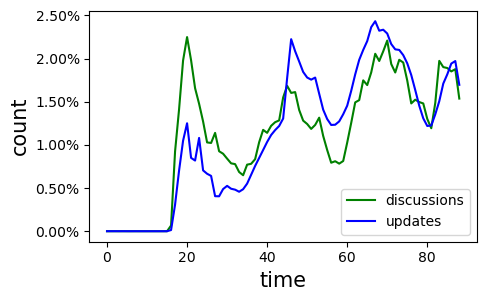

In [12]:
fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
X = np.arange(0, 89)
plt.plot(X, c_p_hour, c= 'g', label = "discussions")
plt.plot(X, updates_hour, c='b', label="updates")
ax.set_ylabel('count', fontsize=15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc = 'lower right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

# Place mentions from March 30 - End of April

In [3]:
start_time = 1490832288
RS_file_lst = ["/scratch/tl107/reddit_thread/reddit-data/RS_2017-03","/scratch/tl107/reddit_thread/reddit-data/RS_2017-04"]
RC_file_lst = ["/scratch/tl107/reddit_thread/reddit-data/RC_2017-03","/scratch/tl107/reddit_thread/reddit-data/RC_2017-04"]
time_count = mention_over_time(RS_file_lst, RC_file_lst, start_time)

Text(0.5, 0, 'time')

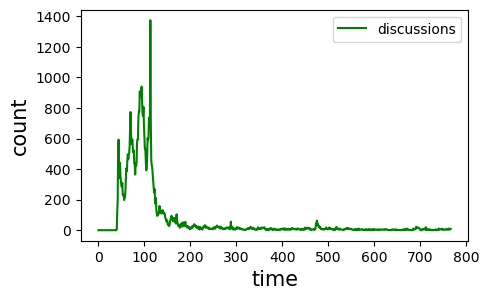

In [8]:
fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
X = np.arange(0, max(time_count.keys()))
Y = np.zeros(len(X))
for i in range(0, len(X)):
    if X[i] in time_count:
        Y[i] = time_count[X[i]]
plt.plot(X, Y, c= 'g', label = "discussions")
# plt.plot(X, updates_hour, c='b', label="updates")
ax.set_ylabel('count', fontsize=15)
# ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc = 'upper right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

# Last time stamp here is : Sunday, April 30, 2017 11:04:48 PM

# Peak is at ~110 hours : Monday, April 3, 2017 2:04:48 PM

# Place experiment ended: Monday, April 3, 2017 4:58:54 PM

In [9]:
max(time_count.keys())

767


# Separating communities by category

Technology: anything associated with tech, such as crypto, space X

Region: countries or cities, some region on the map

Game: games

Screen Entertainment: Some form of video entertainment, such as TV shows or cartoons

Celebrity: include famous people or bands (groups of people)

University: Organizations associated with universities, such as UT Austin, or some clubs belonging to a university

Sports: Sport teams, sport players, esport is also included

YouTubers/Streamers: YouTubers or Streamers, not really celebrities, more like influencers

Other: anything else, such as animals, meme pages

In [107]:
def format_dict(dictionary):
    # Format label to print nicely on plots
    dictionary['Technology'] =  dictionary.pop('tech')
    dictionary['Region'] =  dictionary.pop('nation')
    dictionary['Other'] =  dictionary.pop('other')
    dictionary['Game'] =  dictionary.pop('game')
    dictionary['Screen Entertainment'] =  dictionary.pop('shows')
    dictionary['Celebrity'] =  dictionary.pop('celebrity')
    dictionary['University'] =  dictionary.pop('university')
    dictionary['Sports'] =  dictionary.pop('sports')
    dictionary['YouTubers/Streamers'] =  dictionary.pop('youtubers/streamers')

In [108]:
category = {}
with open(subreddit_category_path, "r") as file:
    reader = csv.reader(file)

    for line in reader:
        cate = line[1]
        if cate == "":
            continue
        if cate.lower() not in category:
            category[cate.lower()] = 1
        else:
            category[cate.lower()] += 1
format_dict(category)

In [36]:
category

{'r/place only': 35,
 'Technology': 34,
 'Region': 167,
 'Other': 132,
 'Game': 159,
 'Screen Entertainment': 96,
 'Celebrity': 41,
 'University': 49,
 'Sports': 63,
 'YouTubers/Streamers': 25}

ValueError: Invalid RGBA argument: 'r/place only'

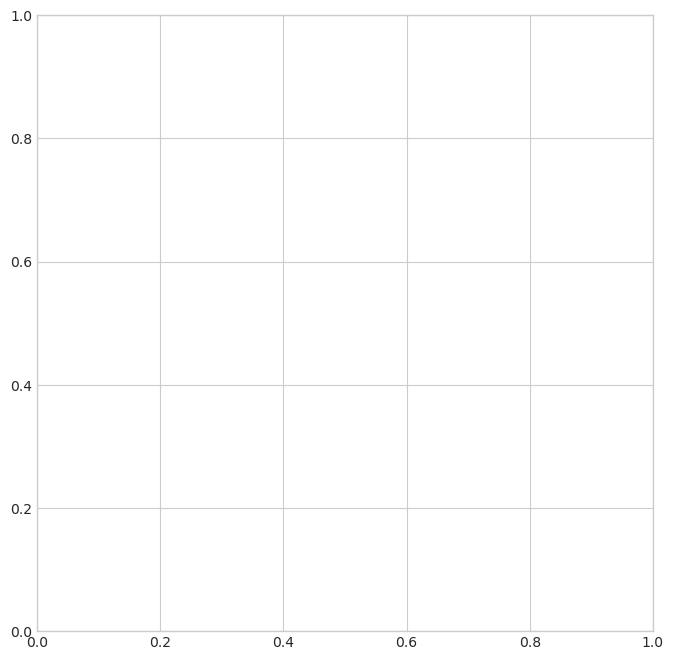

In [109]:
plt.figure(figsize=(8,8))
labels = list(category.keys())

values = list(category.values())
plt.pie(
    x=values, 
    labels=labels,
    # show percentage with two decimal points
    autopct='%1.1f%%',
    # increase the size of all text elements
    textprops={'fontsize':12},
    colors=colors
)

# Are sizes related to categories? Average Number of size per category

In [110]:
subreddit_category = {}
with open(subreddit_category_path, "r") as file:
    reader = csv.reader(file)

    for line in reader:
        subreddit = line[0]
        cate = line[1]
        if subreddit == "" or cate == "":
            continue
        if subreddit.lower() not in subreddit_category:
            subreddit_category[subreddit.lower()] = cate.lower()
        else:
            subreddit_category[subreddit.lower()] += cate.lower()

In [111]:
cate_count = {}
cate_id = {}
cate_pix = {}
for subreddit, cate in subreddit_category.items():
    if cate not in cate_id:
        cate_id[cate] = set()
        cate_pix[cate] = 0
        cate_count[cate] = 0
    id_list = subr_id[subreddit]
    for id in id_list:
        id = str(id)
        if id in cate_id[cate]:
            continue
        else:
            cate_id[cate].add(id)
        if id in pixels_proj_17:
            size = pixels_proj_17[id]
            cate_pix[cate] += size
    cate_count[cate] += 1
for cate in cate_pix:
    cate_pix[cate] /= cate_count[cate]

In [112]:
format_dict(cate_pix)

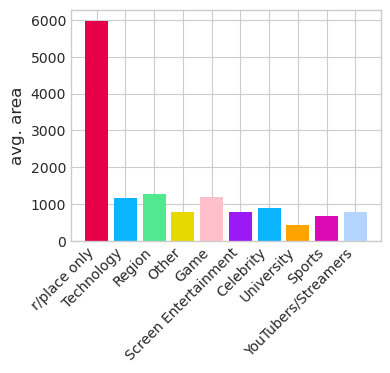

In [120]:
names = list(cate_pix.keys())
values = list(cate_pix.values())
plt.figure(figsize=(4,3))

plt.bar(names, values,color=["#e60049","#0bb4ff", "#50e991", "#e6d800","#FFC0CB", "#9b19f5", "#0bb4ff","#ffa300", "#dc0ab4", "#b3d4ff", "#00bfa0"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("avg. area", size=12)
plt.show()

# Average number of discussions in each categories

In [421]:
cate_discussion = {}
for subreddit, cate in subreddit_category.items():
    if subreddit in comm_post_per_proj:
        size = comm_post_per_proj[subreddit]
        if cate not in cate_discussion:
            cate_discussion[cate] = 0
        cate_discussion[cate] += size
for cate in cate_discussion:
    cate_discussion[cate] /= cate_count[cate]


In [422]:
format_dict(cate_discussion)

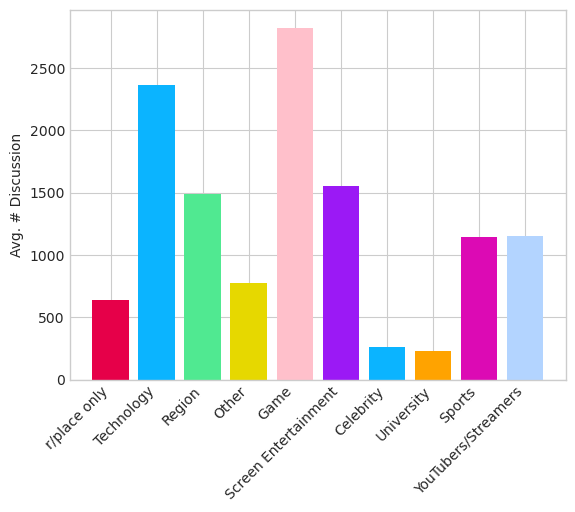

In [444]:
names = list(cate_discussion.keys())
values = list(cate_discussion.values())
plt.bar(names, values,color=["#e60049","#0bb4ff", "#50e991", "#e6d800","#FFC0CB", "#9b19f5", "#0bb4ff","#ffa300", "#dc0ab4", "#b3d4ff", "#00bfa0"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("avg. # discussion")
plt.show()

# Average number of users per category

In [114]:
cate_user = {}
for subreddit, cate in subreddit_category.items():
    if cate not in cate_user:
        cate_user[cate] = 0
    if subreddit in u_per_proj:
        num_user = u_per_proj[subreddit]
        cate_user[cate] += num_user
for cate in cate_user:
    cate_user[cate] /= cate_count[cate]
format_dict(cate_user)

In [115]:
cate_user

{'r/place only': 197.42857142857142,
 'Technology': 747.8235294117648,
 'Region': 337.49101796407183,
 'Other': 238.08333333333334,
 'Game': 764.566037735849,
 'Screen Entertainment': 483.9895833333333,
 'Celebrity': 97.34146341463415,
 'University': 80.42857142857143,
 'Sports': 263.36507936507934,
 'YouTubers/Streamers': 430.2}

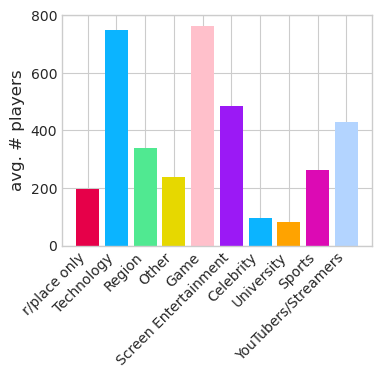

In [117]:
names = list(cate_user.keys())
values = list(cate_user.values())
plt.figure(figsize=(4,3))
plt.bar(names, values,color=["#e60049","#0bb4ff", "#50e991", "#e6d800","#FFC0CB", "#9b19f5", "#0bb4ff","#ffa300", "#dc0ab4", "#b3d4ff", "#00bfa0"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("avg. # players",size=12)
plt.show()

# Discussion Per User

In [227]:
cate_discussion = {}
for subreddit, cate in subreddit_category.items():
    if subreddit in comm_post_per_proj:
        size = comm_post_per_proj[subreddit]
        if cate not in cate_discussion:
            cate_discussion[cate] = 0
        cate_discussion[cate] += size
format_dict(cate_discussion)
cate_user = {}
for subreddit, cate in subreddit_category.items():
    if cate not in cate_user:
        cate_user[cate] = 0
    if subreddit in u_per_proj:
        num_user = u_per_proj[subreddit]
        cate_user[cate] += num_user
format_dict(cate_user)

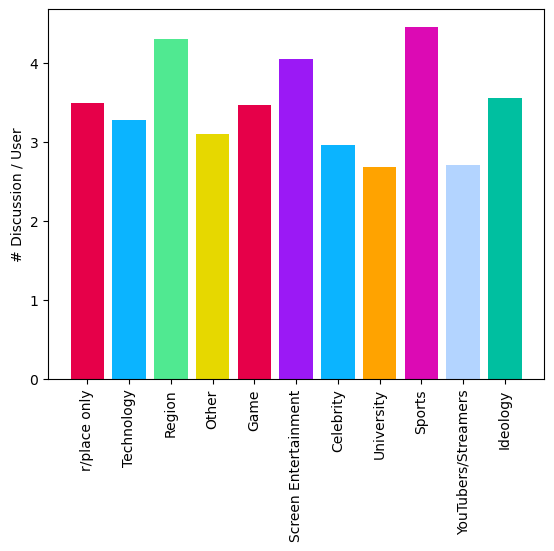

In [228]:
names = list(cate_user.keys())
values = []
for name in names:
    values.append(cate_discussion[name] / cate_user[name])
plt.bar(names, values,color=["#e60049","#0bb4ff", "#50e991", "#e6d800","#e60049", "#9b19f5", "#0bb4ff","#ffa300", "#dc0ab4", "#b3d4ff", "#00bfa0"])
plt.xticks(rotation='vertical')
plt.ylabel("# Discussion / User")
plt.show()

# Total number of users

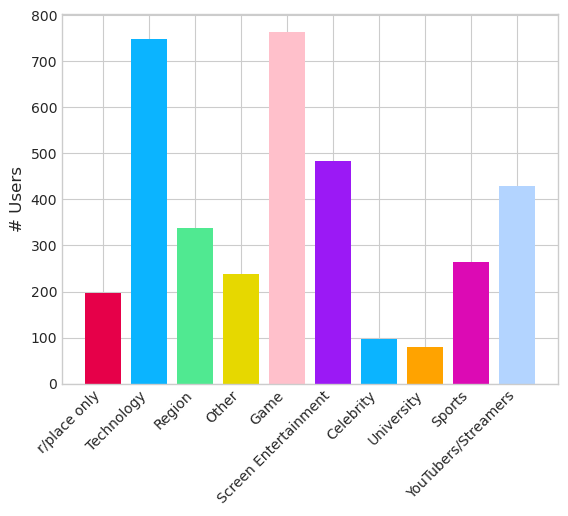

In [454]:
names = list(cate_user.keys())
values = list(cate_user.values())
plt.bar(names, values,color=["#e60049","#0bb4ff", "#50e991", "#e6d800","#FFC0CB", "#9b19f5", "#0bb4ff","#ffa300", "#dc0ab4", "#b3d4ff", "#00bfa0"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("# Users",size=12)
plt.show()

# Total Number of Discussions

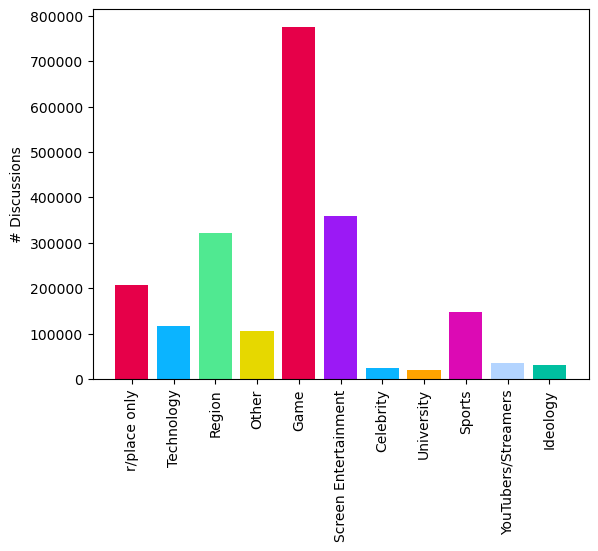

In [230]:
names = list(cate_discussion.keys())
values = list(cate_discussion.values())
plt.bar(names, values,color=["#e60049","#0bb4ff", "#50e991", "#e6d800","#e60049", "#9b19f5", "#0bb4ff","#ffa300", "#dc0ab4", "#b3d4ff", "#00bfa0"])
plt.xticks(rotation='vertical')
plt.ylabel("# Discussions")
plt.show()

# Number of independent artworks by category

In [231]:
cate_art = {}
cate_id = {}
for subreddit, cate in subreddit_category.items():
    if cate not in cate_id:
        cate_id[cate] = set()
        cate_art[cate] = 0
    id_list = subr_id[subreddit]
    for id in id_list:
        if id in cate_id[cate]:
            continue
        else:
            cate_id[cate].add(id)
            cate_art[cate] += 1

In [232]:
format_dict(cate_art)

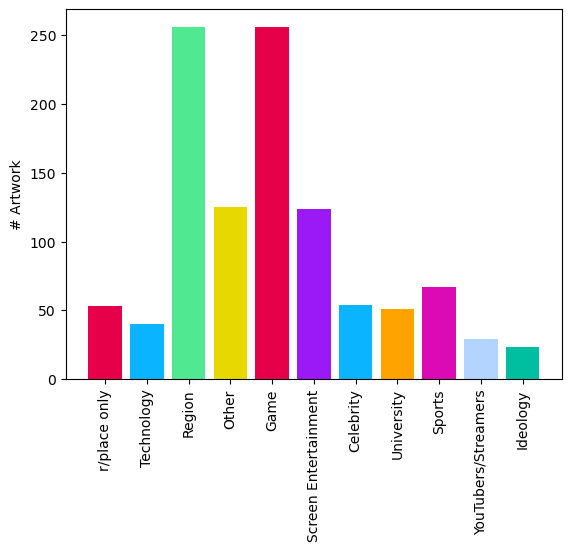

In [233]:
names = list(cate_art.keys())
values = list(cate_art.values())
plt.bar(names, values,color=["#e60049","#0bb4ff", "#50e991", "#e6d800","#e60049", "#9b19f5", "#0bb4ff","#ffa300", "#dc0ab4", "#b3d4ff", "#00bfa0"])
plt.xticks(rotation='vertical')
plt.ylabel("# Artwork")
plt.show()

# Analysis from all the histograms and the pie plot

**Amount of subreddits (pie plot)**: Many regions, games, screen entertainment participated. But more subreddit participation doesn't neccassarily mean they will draw larger drawings, it might mean that they are more divided. The larger drawings are actually produced by smalelr categories (r/place only).

**Discussions**: r/place only subreddit really used reddit to discuss, while some categories with more long standing fan bases use other platforms to communicate (maybe discord). Games, technology, screentime entertainment are also using reddit quite a bit. Maybe because it's what most people go to reddit for? Universities probably will have their own way to communicate since they are more physically connected.

**Size of artworks**: r/place only subreddits build much larger artworks. Some other categories (games and regions) build many more artworks, which mean that the average size would be smaller. This makes sense because regions and games are very diverse, and probably cannot agree on a single artwork.

**r/place only subreddits**: These are very short-term communities, including the Blue Corner and the Green Lattice. Most of these subreddits are no longer in use once the event ended. They discussed a lot, and are very successful in terms of size. Going all the way to create a subreddit just for the event might mean that they are more dedicated? However, they didn't make a large amount of artworks. Also, notice from the pie plot that r/place only subreddits are not that many.

**Number of users**: Average number of users and average number of discussion roughly match.

**Discussion per user is pretty much the same**

In [84]:
import seaborn as sns
pixels_lst = list()
labels = list()
for key in pixels_dict:
    labels.append(key)
    pixels_lst.append(np.array([v for k, v in pixels_dict[key].items()]))
# pixels_lst = np.array(pixels_lst)
for i in range(0, len(pixels_lst)):
#     print(pixels_lst[i])
#     print(np.mean(pixels_lst[i]))
    pixels_lst[i] = (pixels_lst[i] - np.mean(pixels_lst[i])) / np.std(pixels_lst[i])

In [85]:
min(pixels_lst[0])

-0.3183706576014712

<Axes: >

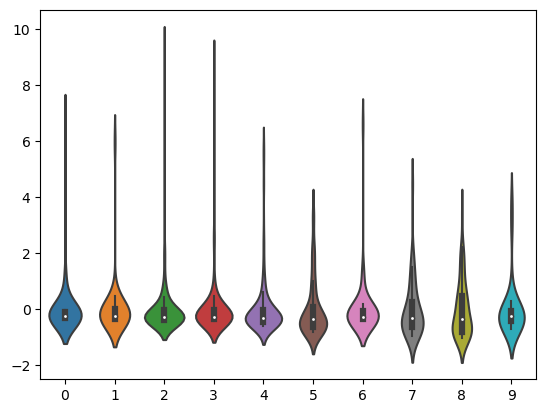

In [86]:
positions = np.arange(1, len(pixels_lst) + 1)
sns.violinplot(pixels_lst)


In [63]:
max(pixels_lst[0])

88281

In [64]:
1001 * 1001

1002001

# Engagement - show no increase in activity 2017

In [38]:
import pickle

In [34]:
def convert_time_hour(start_time, time):
    return math.floor((time - start_time) / 3600)
def count_activity(file_lst, start_time, event_start, event_end):
    event_start = convert_time_hour(start_time, event_start)
    event_end = convert_time_hour(start_time, event_end)
    time_count = dict()
    event_count = dict()
    for f in file_lst:
        with open(f, 'r') as file:
            next(file, None)
            reader = csv.reader(file)
            for line in reader:
                if line[0] != '':
                    t = int(line[0])
                    time = convert_time_hour(start_time, t)
                    if time >= event_start and time <= event_end:
                        if time not in event_count:
                            event_count[time] = 1
                        else:
                            event_count[time] += 1
                    else:
                        if time not in time_count:
                            time_count[time] = 1
                        else:
                            time_count[time] += 1
    return time_count, event_count

In [35]:
# 2017 Time
start_utc = 1490918688
end_utc = 1491238734
file_lst = ["/scratch/yw180/reddit_thread/RC_2017-03_filtered","/scratch/yw180/reddit_thread/RC_2017-04_filtered", "/scratch/yw180/reddit_thread/RS_2017-03_filtered", "/scratch/yw180/reddit_thread/RS_2017-04_filtered"]
start_time = 1488326400
activity_17, event_17 = count_activity(file_lst, start_time, start_utc, end_utc)

In [41]:
with open("/scratch/yw180/reddit_thread/2017_normal.pkl", "rb") as input_file:
    activity_17 = pickle.load(input_file)
    
with open("/scratch/yw180/reddit_thread/2017_event.pkl", "rb") as input_file:
    event_17 = pickle.load(input_file)    

In [42]:
X_left = [key for key in activity_17 if key < min(event_17.keys())]
Y_left = [activity_17[key] for key in activity_17 if key < min(event_17.keys())]
X_event = [key for key in event_17]
Y_event = [event_17[key] for key in event_17]
X_right =  [key for key in activity_17 if key > max(event_17.keys())]
Y_right = [activity_17[key] for key in activity_17 if key > max(event_17.keys())]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'time')

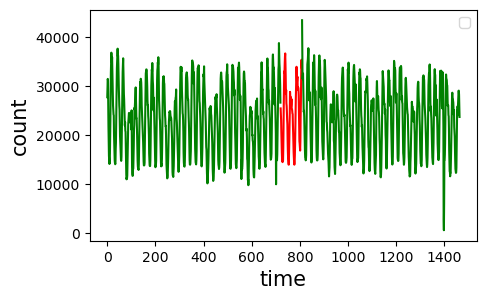

In [43]:
fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
plt.plot(X_left, Y_left, c= 'g')
plt.plot(X_event, Y_event, c= 'r')
plt.plot(X_right, Y_right, c='g')

# plt.plot(X, updates_hour, c='b', label="updates")
ax.set_ylabel('count', fontsize=15)
# ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc = 'upper right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

In [51]:
# Normalize by Seasonality, by week
combined_dict = dict()
for key in activity_17:
    combined_dict[key] = activity_17[key]
for key in event_17:
    if key in combined_dict:
        combined_dict[key] += event_17[key]
    else:
        combined_dict[key] = event_17[key]

In [52]:
diff_dict = dict()
hour_in_week = 24 * 7
for key in combined_dict:
    if key - hour_in_week > 0:
        if key - hour_in_week not in combined_dict:
            diff_dict[key] = combined_dict[key]
        else:
            diff_dict[key] = combined_dict[key] - combined_dict[key - hour_in_week]

In [53]:
X_left = [key for key in diff_dict if key < min(event_17.keys())]
Y_left = [diff_dict[key] for key in diff_dict if key < min(event_17.keys())]
X_event = [key for key in event_17]
Y_event = [diff_dict[key] for key in event_17]
X_right =  [key for key in diff_dict if key > max(event_17.keys())]
Y_right = [diff_dict[key] for key in diff_dict if key > max(event_17.keys())]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'time')

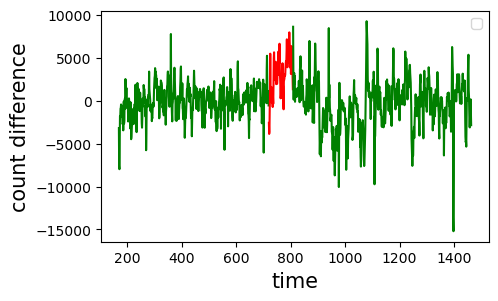

In [54]:
fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
plt.plot(X_left, Y_left, c= 'g')
plt.plot(X_event, Y_event, c= 'r')
plt.plot(X_right, Y_right, c='g')

# plt.plot(X, updates_hour, c='b', label="updates")
ax.set_ylabel('count difference', fontsize=15)
# ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc = 'upper right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

In [55]:
# Plot by day
day_dict = dict()
for i in range(0, max(combined_dict.keys())):
    grp = math.floor(i / 24)
    if grp in combined_dict:
        if grp not in day_dict:
            day_dict[grp] = combined_dict[grp]
        else:
            day_dict[grp] += combined_dict[grp]

In [72]:
X = [key for key in day_dict ]
Y = [day_dict[key] for key in day_dict ]
X_event = [key for key in day_dict if key >= 30 and key <= 33]
Y_event = [day_dict[key] for key in day_dict if key >= 30 and key <= 33]
# X_right =  [key for key in day_dict if key > 33]
# Y_right = [day_dict[key] for key in day_dict if key >33]

In [73]:
X_event

[30, 31, 32, 33]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'time')

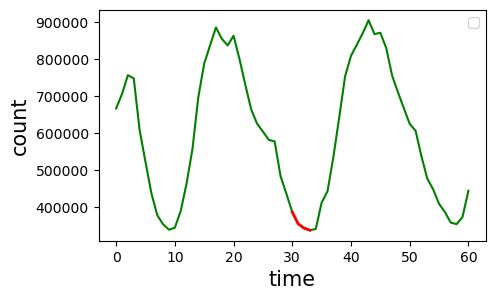

In [83]:
fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
plt.plot(X, Y, c= 'g')
plt.plot(X_event, Y_event, c= 'r', linewidth=2)
# plt.plot(X_right, Y_right, c='g')

# plt.plot(X, updates_hour, c='b', label="updates")
ax.set_ylabel('count', fontsize=15)
# ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc = 'upper right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

In [81]:
# remove Seasonality
norm_X = X[7:]
norm_Y = list()
for i in norm_X:
    norm_Y.append(Y[i] - Y[i - 7])
norm_X_event = [30,31,32,33]
norm_Y_event = [norm_Y[i - 7] for i in norm_X_event]

In [80]:
X[0]

0

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'time')

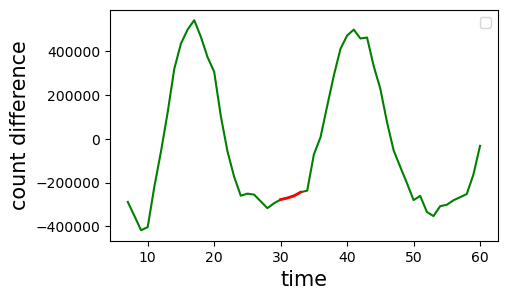

In [82]:
fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)  
plt.plot(norm_X, norm_Y, c= 'g')
plt.plot(norm_X_event, norm_Y_event, c= 'r', linewidth=2)
# plt.plot(X_right, Y_right, c='g')

# plt.plot(X, updates_hour, c='b', label="updates")
ax.set_ylabel('count difference', fontsize=15)
# ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc = 'upper right')

ax.tick_params(labelsize=10)
ax.set_xlabel('time', fontsize=15)

In [79]:
norm_Y

[7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7]